# Bavarian Real Estate Market Analysis  
### Pricing, Liquidity, Segmentation, and Listing Behavior


## Introduction

This project analyzes the Bavarian rental housing market using large-scale listing data to 
understand rental price formation, market liquidity, and structural segmentation.

By combining exploratory data analysis, regression modeling, clustering techniques, 
geospatial analysis, and textual analysis of listings, the study provides a comprehensive, 
data-driven view of how property characteristics, location, and listing behavior influence 
rental outcomes.


In [1]:
import pandas as pd
import numpy as np


In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df= pd.read_csv('/Users/AK/Documents/data analytics with python final presentation/realestate_data_BV.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235930 entries, 0 to 235929
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   _id                       235930 non-null  object 
 1   firstSeen                 235930 non-null  object 
 2   lastSeen                  235930 non-null  object 
 3   platforms                 235930 non-null  object 
 4   area                      220444 non-null  float64
 5   auction                   235930 non-null  bool   
 6   balcony                   230488 non-null  object 
 7   balconyOrTerrace          173110 non-null  object 
 8   barrierFree               119526 non-null  object 
 9   bathrooms                 168435 non-null  float64
 10  boostedListing            235930 non-null  bool   
 11  buyersOneTimeCosts        94196 non-null   float64
 12  cellarOrAttic             179586 non-null  object 
 13  daysActive                235930 non-null  f

## Dataset Overview

The dataset contains 235,929 ** residential rental listings**, capturing key information 
about pricing, property characteristics, location, and listing behavior.

### Core Data Categories

- **Price & Market Dynamics**  
  Rent, price per square meter, listing duration, and time-on-market indicators.

- **Property Characteristics**  
  Apartment size, number of bathrooms, floor level, building structure, and estate type.

- **Amenities & Features**  
  Balcony, lift, garden, furnishing status, accessibility, and construction age.

- **Location Information**  
  City, ZIP code, district, state, and geographic coordinates.

- **Listing & Platform Information**  
  Advertising platform, offerer type, commission status, and listing boosts.

- **Textual Information**  
  Listing titles used for text-based analysis.



## Data Cleaning & Preprocessing

For interpretability, the dataset was filtered and cleaned prior to analysis.

Key preprocessing steps included:
- Removal of values for rent, area, 
- Filtering extreme outliers 
- Handling missing values in non-critical fields
- Feature engineering (e.g., price per square meter)



In [4]:
## 1. first and last seen
## CONVERT TO DATETIME ---
df['firstSeen'] = pd.to_datetime(df['firstSeen'], errors='coerce')
df['lastSeen'] = pd.to_datetime(df['lastSeen'], errors='coerce')

## 2. area- dropping missing values
df = df.dropna(subset=["area"])

## 3. Balcony- assigning nan as False
df["balcony"] = (df["balcony"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## 4. Balcony or Terrace- assigning nan as False
df["balconyOrTerrace"] = (df["balconyOrTerrace"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## 5. Barrier Free- assigning nan as False
df["barrierFree"] = (df["barrierFree"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

##. 6. cellar- attic- assigning nan as False
df["cellarOrAttic"] = (df["cellarOrAttic"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## 7. Garden- assigning nan as false
df["garden"] = (df["garden"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## 8. Lift- assigning nan as false
df["lift"] = (df["lift"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## 9. Furnished- assigning nan as false
df["furnished"] = (df["furnished"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## 10. Price- Fixing outliers- we consider any price below 150 and above 8000 as faulty data.  
df = df[(df["price"] >= 150) & (df["price"] <= 8000)]

## 11. bathrooms- 
# Fixing outliers- we consider anything anything above 5 as a data error and default it to 1
df.loc[df['bathrooms'] > 5, 'bathrooms'] = 1.0

# Missing Values- : We replace all NaN values with 1 assumpting every household with least of 1 bathroom.
df['bathrooms'] = df['bathrooms'].fillna(1.0)
df['bathrooms'] = df['bathrooms'].astype(int)

## 12. Buyer One Time costs- For values not given we assume no costs involved. 
df['buyersOneTimeCosts'] = df['buyersOneTimeCosts'].fillna(0)

/var/folders/y3/9gvskmz92w9497s4v4tvb1k80000gn/T/ipykernel_24949/845502524.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["balcony"] = (df["balcony"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))
/var/folders/y3/9gvskmz92w9497s4v4tvb1k80000gn/T/ipykernel_24949/845502524.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["balconyOrTerrace"] = (df["balconyOrTerrace"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))
/var/folders/y3/9gvskmz9

In [5]:
## 13. Real Estate Type- to categorise the type of property on listing.  
def refine_estate_type(row):
    existing_type = str(row['estateTypeSpecified']) if pd.notna(row['estateTypeSpecified']) else ""
    title = str(row['title']).lower() if pd.notna(row['title']) else ""
    
    # 2. FLAG "SWAP FLATS"
    if 'tausch' in title:
        return 'Swap_Flat'
    
    # Shared Flats (WG)
    if 'wg ' in title or 'wg-zimmer' in title or 'wohngemeinschaft' in title:
        return 'Shared_Apartment'
        
    # check for keywords
    house_keywords = ['haus', 'dhh', 'reiheneckhaus', 'doppelhaushälfte', 'bungalow', 'villa']
    if any(keyword in title for keyword in house_keywords):
        return 'House'
        
    # Roof/Penthouse
    if 'penthouse' in title:
        return 'Penthouse'
    if 'dachgeschoss' in title or 'dachwohnung' in title:
        return 'Roof_Storey'
        
    # Maisonette / Loft
    if 'maisonette' in title:
        return 'Maisonette'
    if 'loft' in title:
        return 'Loft'
        
    # Basement
    if 'souterrain' in title or 'einliegerwohnung' in title:
        return 'Basement'

    # If the existing category is valid (not nan or unspecified), keep it
    if existing_type and existing_type != 'nan' and existing_type != 'unspecifiedApartment':
        return existing_type

    # 5. using floor for determining
    floor = row.get('floor', float('nan'))
    if floor == 0:
        return 'groundFloorApartment'
    elif floor > 0:
        return 'midFloorApartment' 
        
    return 'midFloorApartment'

df['estateTypeSpecified'] = df.apply(refine_estate_type, axis=1)

# Checking result
print(df['estateTypeSpecified'].value_counts())

estateTypeSpecified
midFloorApartment        115327
groundFloorApartment      24566
House                     24044
roofStoreyApartment       17896
Roof_Storey                7259
terracedApartment          4430
Maisonette                 3951
Swap_Flat                  2928
Shared_Apartment           2565
maisonetteApartment        2388
Penthouse                  1887
singleFamilyHouse          1380
Basement                   1379
halfBasementApartment      1376
Loft                        935
penthouse                   648
sharedApartment             408
semidetachedHouse           372
loft                        312
midTerraceHouse             255
unspecifiedHouse            153
endTerraceHouse             149
terraceHouse                 89
villa                        77
bungalow                     27
other                         5
multiFamilyHouse              1
Name: count, dtype: int64


In [6]:
## 14. Number of Floors- The construction of high-rise buildings is not common in German cities, and as checked on wikipedia, we assume on
##     the maximum number of floors as 10. 
df.loc[df["numberOfFloors"] > 10, "numberOfFloors"] = pd.NA
df["numberOfFloors"] = df["numberOfFloors"].astype("Int64")

## 15. Floors- max floors being 10, floors therefore;
df.loc[df["floor"] > 10, "floor"] = np.nan
df["floor"] = df["floor"].astype("Int64")

In [7]:
## 16. Cleaning titles for special characters- for clarity and textual analysis
import html

def clean_title(text):
    if pd.isna(text):
        return pd.NA
    text = html.unescape(str(text))
    replacements = {
        'Ã¼': 'ü', 'Ã¶': 'ö', 'Ã¤': 'ä', 'ÃŸ': 'ß',
        '√∂': 'ö', '√§': 'ä', '√u': 'ü', '√fc': 'ü', '√ue': 'ß'
    }
    for k, v in replacements.items():
        text = text.replace(k, v)
    return text.lower()

df["title"] = df["title"].apply(clean_title)


In [8]:
## Drop the specific columns
# inplace=True modifies the dataframe directly without needing to reassign it
df.drop(columns=['state', 'parsed', 'year'], inplace=True)

## dropping rows where no price and rent available.
df = df.dropna(subset=["price", "totalRent"], how="all")






In [9]:
## expanding information stored in location and offerer columns 
df = df.reset_index(drop=True)
import ast

def safe_parse(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return {}
    return {}

df["location"] = df["location"].apply(safe_parse)
df["offerer"] = df["offerer"].apply(safe_parse)

loc_df = pd.json_normalize(df["location"])
loc_df.index = df.index
loc_df = loc_df.add_prefix("location_")

off_df = pd.json_normalize(df["offerer"])
off_df.index = df.index
off_df = off_df.add_prefix("offerer_")

df = df.drop(columns=["location", "offerer"]).join(loc_df).join(off_df)


In [10]:
## extracting zip codes and cities
df['location_zipCity'] = df['location_zipCity'].astype(str).str.strip()

df['zip'] = df['location_zipCity'].str[:5]
df['city'] = df['location_zipCity'].str[5:].str.strip()

## in the dataset, 1 value comes out to be missing where zip code was missing, since it was the only one, we manually find the detail and correct it in the dataset.
mask = df['location_zipCity'].str.contains('Pielenhofen', case=False, na=False)
df.loc[mask, 'zip'] = 93188
df.loc[mask, 'city'] = 'Pielenhofen'

df['zip'] = df['zip'].astype(int)





In [11]:
## extracting latitudes and longitudes
# 1. Define the extractor function
def extract_coords(val):
    # Check if the value is a list and has exactly 2 items
    if isinstance(val, list) and len(val) == 2:
        return val[1], val[0] # Return Latitude (49.x), Longitude (11.x)
    return np.nan, np.nan

# 2. Apply it to the dataframe
# This creates two new columns: 'lat' and 'lon'
df[['lat', 'lon']] = df['location_coordinates.coordinates'].apply(
    lambda x: pd.Series(extract_coords(x))
)

# 3. Check the result
print(df[['location_coordinates.coordinates', 'lat', 'lon']].head())

  location_coordinates.coordinates        lat        lon
0             [11.28971, 49.29684]  49.296840  11.289710
1            [9.910261, 49.815826]  49.815826   9.910261
2            [10.24402, 50.066227]  50.066227  10.244020
3           [11.576849, 48.101852]  48.101852  11.576849
4            [9.910261, 49.815826]  49.815826   9.910261


In [12]:
## offerer commission- assigning nan as false and converting to bool values
df["offerer_commission"] = (df["offerer_commission"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## unidentified offerer- assigning nan as false and converting to bool values
df["offerer_unidentifiedOfferer"] = (df["offerer_unidentifiedOfferer"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))

## boosting agent - assigning nan as false and converting to bool values
df["offerer_boostingAgent"] = (df["offerer_boostingAgent"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))


/var/folders/y3/9gvskmz92w9497s4v4tvb1k80000gn/T/ipykernel_24949/488723997.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["offerer_commission"] = (df["offerer_commission"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(False).astype(bool))
/var/folders/y3/9gvskmz92w9497s4v4tvb1k80000gn/T/ipykernel_24949/488723997.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["offerer_unidentifiedOfferer"] = (df["offerer_unidentifiedOfferer"].astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False}).fillna(Fal

In [13]:
df = df.drop(columns=['location_zipCity','location_city', 'location_zip','location_coordinates.type','offerer_id','offerer_platformUrl','offerer_logoUrl',
                      'offerer_anbieterId', 'offerer_name','offerer_email','offerer_emailDomain','offerer_phoneNumber','offerer_allPhoneNumbers','offerer_website',
                      'offerer_hrbNumber','offerer_hraNumber','offerer_vatId','offerer_vatNumber','offerer_ebayStoreId','offerer_anbieter_id','offerer_location.zip',
                      'offerer_location.city','offerer_location.street','offerer_location.zipCity','offerer_location.county','offerer_location.state','offerer_location.coordinates.coordinates',
                      'offerer_location.coordinates.type','offerer_commissionPercentage','offerer_commission_raw', 'offerer_company_not_normalized', 'offerer_company_formatted',
                      'offerer_platforms', 'location_coordinates.coordinates'])


In [14]:
# exploring data
print(df['zip'].astype(str).str.replace(r'\.0$', '', regex=True).str[0].value_counts().sort_index())
df = df[df['zip'].astype(str).str.startswith(('8', '9'))]


zip
1        10
2         8
3         5
4        11
5        11
6      5833
7        29
8    118657
9     90243
Name: count, dtype: int64


Bavaria (Bayern) in Germany uses a 5-digit postal code system (PLZ), with codes generally starting with 8 or 9, and since we were analysing bavaria we removed zipcodes starting any other number i.e cities outside bavaria.

In [15]:
## feature engineering for further analysis
df['price_m2'] = df['price'] / df['area']

## month of posting
df['month'] = pd.to_datetime(df['firstSeen']).dt.month


## 4. Exploratory Data Analysis (EDA)

Exploratory analysis was conducted to understand the overall distribution of rents, property 
sizes, and market liquidity.

Key observations from the EDA include:
- Rental prices and price per square meter are right-skewed, indicating strong price dispersion
- Larger apartments generally exhibit lower price per square meter
- Days active varies significantly across listings, suggesting differences in demand and 
  market fit
- Seasonal patterns are visible, with higher listing activity during specific months

These findings motivated deeper modeling and segmentation analyses.


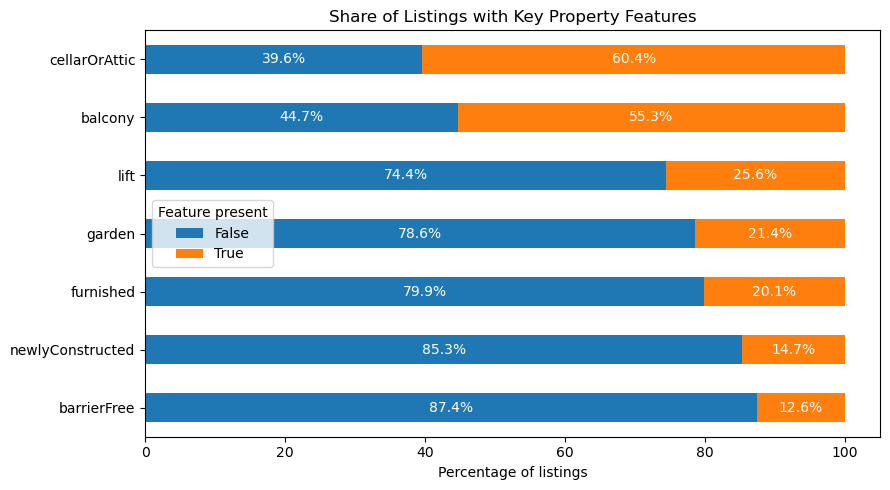

            feature  True_count  False_count  True_%  False_%
0           balcony      115572        93328   55.32    44.68
1              lift       53452       155448   25.59    74.41
2            garden       44692       164208   21.39    78.61
3         furnished       42059       166841   20.13    79.87
4  newlyConstructed       30718       178182   14.70    85.30
5       barrierFree       26329       182571   12.60    87.40
6     cellarOrAttic      126121        82779   60.37    39.63


In [16]:
## exploring features
import matplotlib.pyplot as plt

features = [
    'balcony','lift','garden','furnished','newlyConstructed','barrierFree','cellarOrAttic']
# % of True values
true_pct = df[features].mean() * 100
false_pct = 100 - true_pct

plot_df = (
    pd.DataFrame({'False': false_pct,'True': true_pct}).sort_values('True'))

# Plotting
ax = plot_df.plot(
    kind='barh',
    stacked=True,
    figsize=(9, 5)
)

# Adding labels
for i, (false, true) in enumerate(zip(plot_df['False'], plot_df['True'])):
    if false > 5:
        ax.text(false / 2, i, f"{false:.1f}%", va='center', ha='center', color='white')
    if true > 5:
        ax.text(false + true / 2, i, f"{true:.1f}%", va='center', ha='center', color='white')

# Formatting
ax.set_xlabel('Percentage of listings')
ax.set_title('Share of Listings with Key Property Features')
ax.legend(title='Feature present')

plt.tight_layout()
plt.show()

feature_summary = []

for col in features:
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100

    feature_summary.append({
        "feature": col,
        "True_count": counts.get(True, 0),
        "False_count": counts.get(False, 0),
        "True_%": round(pct.get(True, 0), 2),
        "False_%": round(pct.get(False, 0), 2),
    })

feature_summary_df = pd.DataFrame(feature_summary)
print(feature_summary_df)



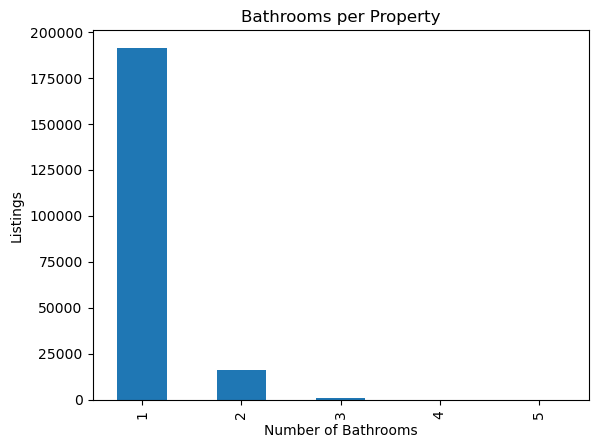

           Listings  Percentage (%)
bathrooms                          
1            191356           91.60
2             16103            7.71
3              1266            0.61
4               144            0.07
5                31            0.01


In [17]:
## number of bathrooms
plt.figure()
df['bathrooms'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Listings')
plt.title('Bathrooms per Property')
plt.show()

bathroom_counts = df['bathrooms'].value_counts().sort_index()
bathroom_pct = df['bathrooms'].value_counts(normalize=True).sort_index() * 100

bathroom_summary = pd.DataFrame({
    'Listings': bathroom_counts,
    'Percentage (%)': bathroom_pct.round(2)
})

print(bathroom_summary)



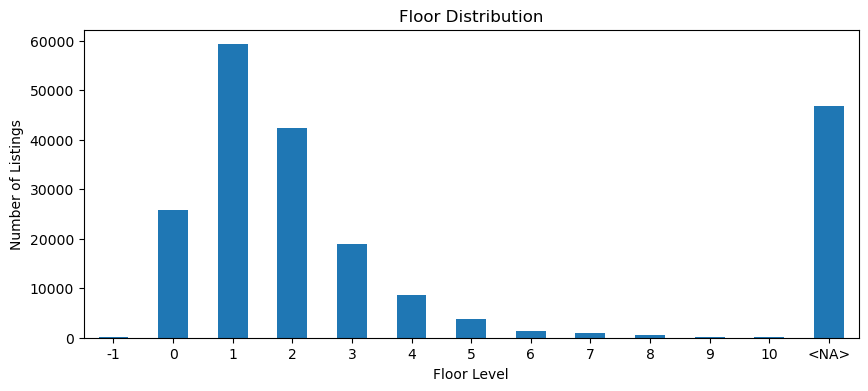

                Listings  Percentage (%)
numberOfFloors                          
0                    548             0.7
1                   5247             6.7
2                  26459           33.78
3                  22539           28.78
4                  12544           16.01
5                   6096            7.78
6                   2375            3.03
7                   1078            1.38
8                   1081            1.38
9                    224            0.29
10                   137            0.17


In [18]:
## Floor distribution
plt.figure(figsize=(10, 4))
df['floor'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.xlabel('Floor Level')
plt.ylabel('Number of Listings')
plt.title('Floor Distribution')
plt.xticks(rotation=0)
plt.show()

floors_counts = df['numberOfFloors'].value_counts().sort_index()
floors_pct = df['numberOfFloors'].value_counts(normalize=True).sort_index() * 100

floors_summary = pd.DataFrame({
    'Listings': floors_counts,
    'Percentage (%)': floors_pct.round(2)
})

print(floors_summary)



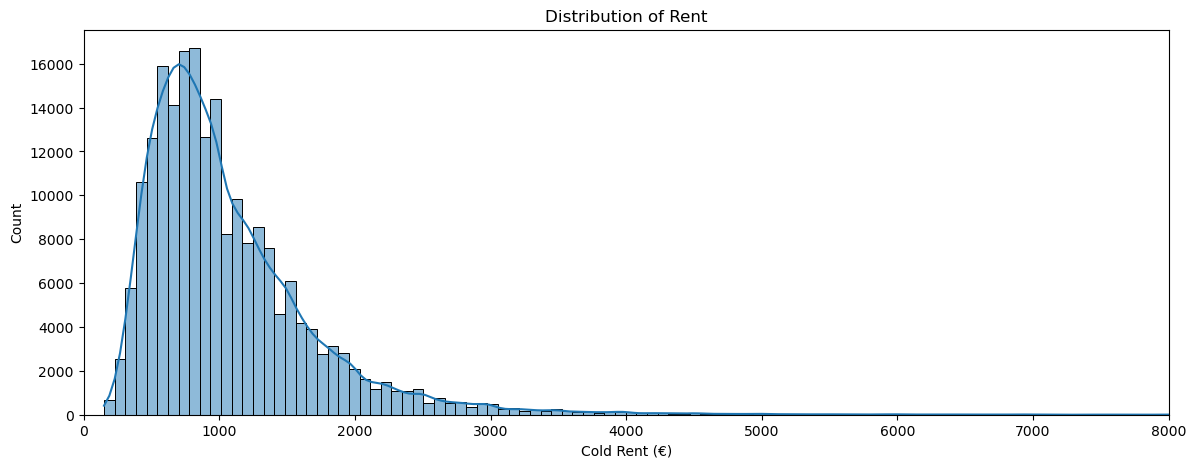

count    208900.000000
mean       1072.117074
std         647.459782
min         150.000000
25%         650.000000
50%         900.000000
75%        1320.000000
max        8000.000000
Name: price, dtype: float64


In [19]:
## exploring price distribution
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 5))

sns.histplot(df['price'], bins=100, kde=True, ax=ax)
ax.set_title('Distribution of Rent', fontsize=12)
ax.set_xlabel('Cold Rent (€)')
ax.set_xlim(0, 8000)

plt.show()

print(df['price'].describe())





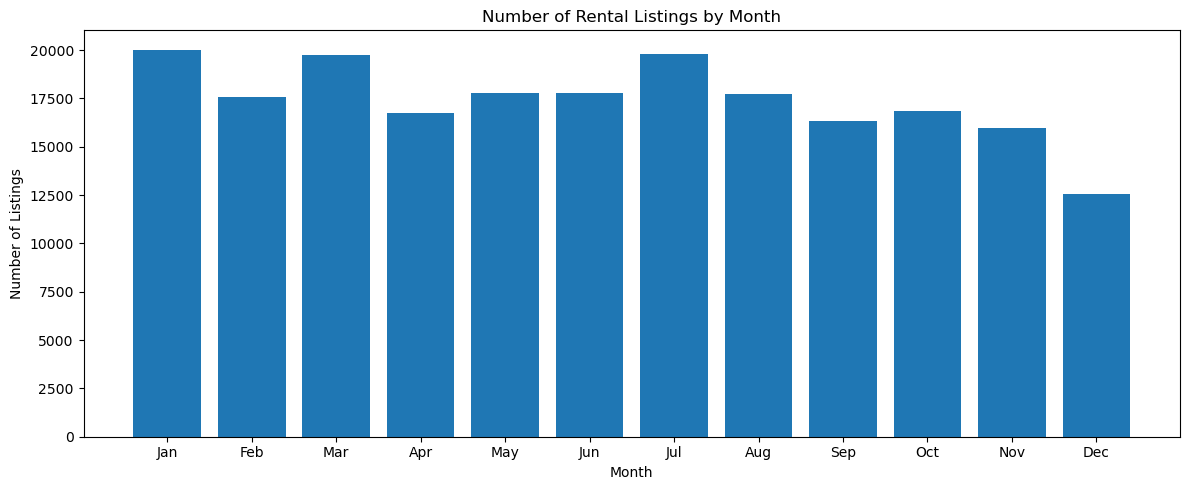

     Listings  Percentage (%)
Jan     20020            9.58
Feb     17591            8.42
Mar     19761            9.46
Apr     16727            8.01
May     17761            8.50
Jun     17805            8.52
Jul     19782            9.47
Aug     17716            8.48
Sep     16355            7.83
Oct     16848            8.07
Nov     15992            7.66
Dec     12542            6.00


In [20]:
import calendar
import matplotlib.pyplot as plt

monthly_listings = df.groupby('month').size().sort_index()

month_names = [calendar.month_abbr[m] for m in monthly_listings.index]

plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_listings.values)

plt.title('Number of Rental Listings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Listings')

plt.tight_layout()
plt.show()

monthly_summary = pd.DataFrame({
    'Listings': monthly_listings,
    'Percentage (%)': (monthly_listings / monthly_listings.sum() * 100).round(2)
})

monthly_summary.index = [calendar.month_abbr[m] for m in monthly_summary.index]

print(monthly_summary)


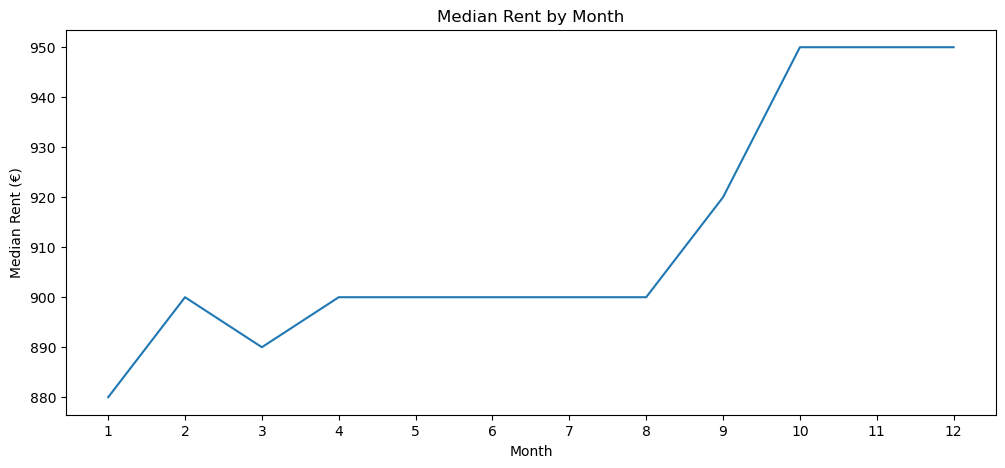

   Month  Listings  Median_Rent
0    Jan     20020        880.0
1    Feb     17591        900.0
2    Mar     19761        890.0
3    Apr     16727        900.0
4    May     17761        900.0
5    Jun     17805        900.0
6    Jul     19782        900.0
7    Aug     17716        900.0
8    Sep     16355        920.0
9    Oct     16848        950.0
10   Nov     15992        950.0
11   Dec     12542        950.0


In [21]:
monthly_price = (
    df.groupby('month')['price']
      .median()
      .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_price,
    x='month',
    y='price'
)

plt.title('Median Rent by Month')
plt.xlabel('Month')
plt.ylabel('Median Rent (€)')
plt.xticks(range(1, 13))
plt.show()

monthly_summary = (df.groupby('month')['price'].agg(Listings='count',Median_Rent='median').reset_index())

# summary
monthly_summary['Month'] = monthly_summary['month'].apply(lambda x: calendar.month_abbr[x])
monthly_summary = monthly_summary[['Month', 'Listings', 'Median_Rent']]

print(monthly_summary)


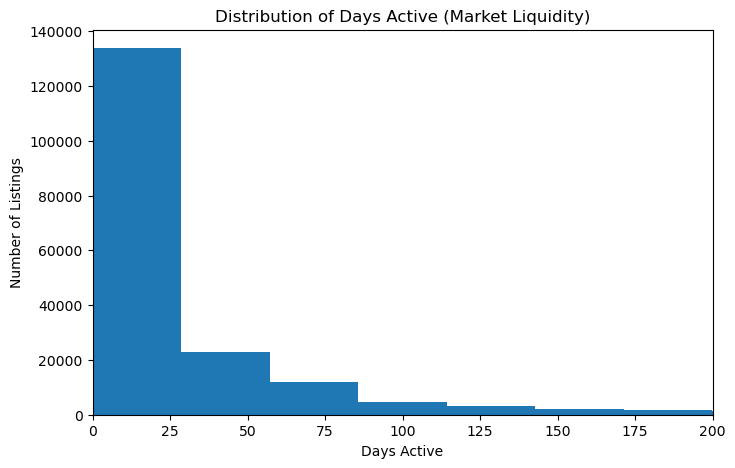

Average days active: 90.1
Median days active: 14.4


In [22]:
## understanding market liquidity
plt.figure(figsize=(8,5))
plt.hist(df['daysActive'], bins=60)
plt.xlabel('Days Active')
plt.ylabel('Number of Listings')
plt.title('Distribution of Days Active (Market Liquidity)')
plt.xlim(0, 200)
plt.show()

print("Average days active:", round(df['daysActive'].mean(), 1))
print("Median days active:", round(df['daysActive'].median(), 1))


/var/folders/y3/9gvskmz92w9497s4v4tvb1k80000gn/T/ipykernel_24949/1260425656.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_bucket')['daysActive']


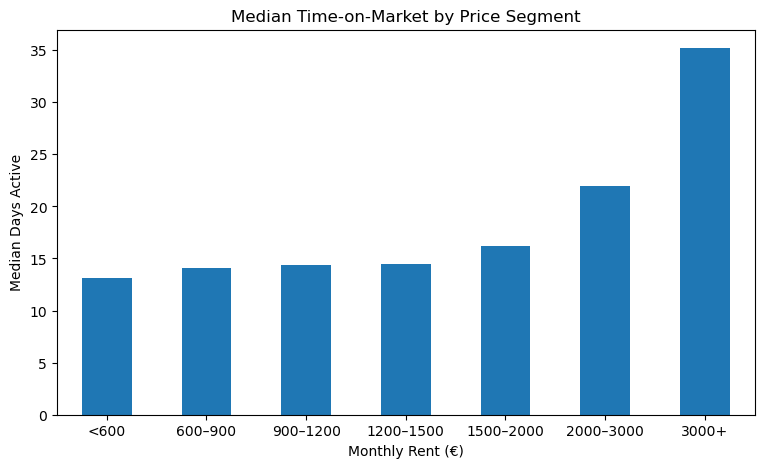

              Listings  Median_Days_Active  Mean_Days_Active
price_bucket                                                
<600             45565                13.2              93.5
600–900          59232                14.1              94.2
900–1200         41112                14.3              90.5
1200–1500        26452                14.5              84.3
1500–2000        21574                16.2              81.4
2000–3000        11613                22.0              81.9
3000+             3352                35.2              96.7


/var/folders/y3/9gvskmz92w9497s4v4tvb1k80000gn/T/ipykernel_24949/1260425656.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_bucket')['daysActive']


In [23]:
price_bins = [0, 600, 900, 1200, 1500, 2000, 3000, np.inf]
price_labels = [
    '<600', '600–900', '900–1200',
    '1200–1500', '1500–2000', '2000–3000', '3000+'
]

df['price_bucket'] = pd.cut(df['price'], bins=price_bins, labels=price_labels)

median_days_by_price = (
    df.groupby('price_bucket')['daysActive']
      .median()
      .reindex(price_labels)
)

plt.figure(figsize=(9,5))
median_days_by_price.plot(kind='bar')
plt.ylabel('Median Days Active')
plt.xlabel('Monthly Rent (€)')
plt.title('Median Time-on-Market by Price Segment')
plt.xticks(rotation=0)
plt.show()

price_bucket_summary = (
    df.groupby('price_bucket')['daysActive']
      .agg(
          Listings='count',
          Median_Days_Active='median',
          Mean_Days_Active='mean'
      )
      .reindex(price_labels)
)

print(price_bucket_summary.round(1))



In [24]:
df['price_m2'].describe()

count    208900.000000
mean         15.461153
std          60.109125
min           0.000025
25%          10.000000
50%          13.173561
75%          18.181818
max       18900.000000
Name: price_m2, dtype: float64

## Market Segmentation via Clustering

To identify structurally distinct segments of the rental market, K-Means clustering was 
applied using standardized price per square meter and living area.


Cluster sample size: 207,936


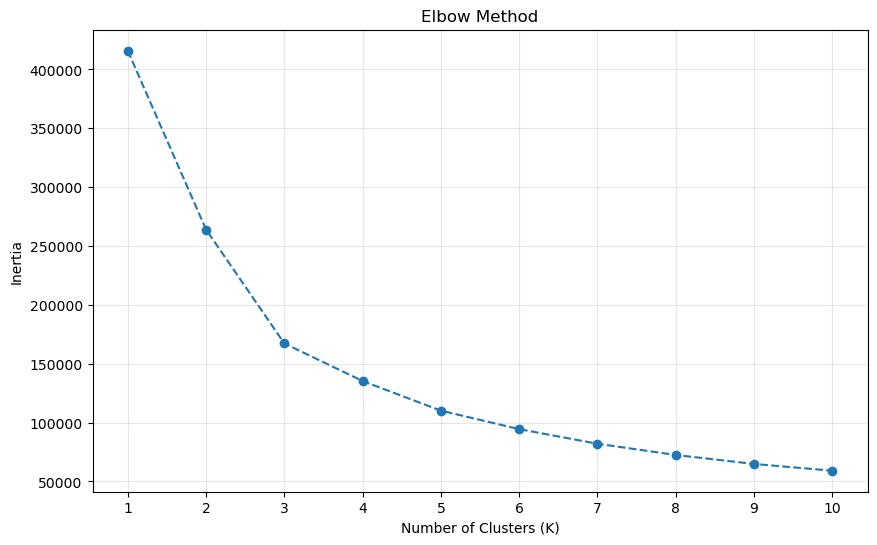

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# filtering data and removing some outliers
mask_valid = (
    (df['price_m2'] > 3) & (df['price_m2'] < 60)
)

cluster_df = df.loc[mask_valid, ['price_m2', 'area']].copy()

print(f"Cluster sample size: {len(cluster_df):,}")

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# elbow method to know number of clusters
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plotting
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.show()


optimal clusters = 3

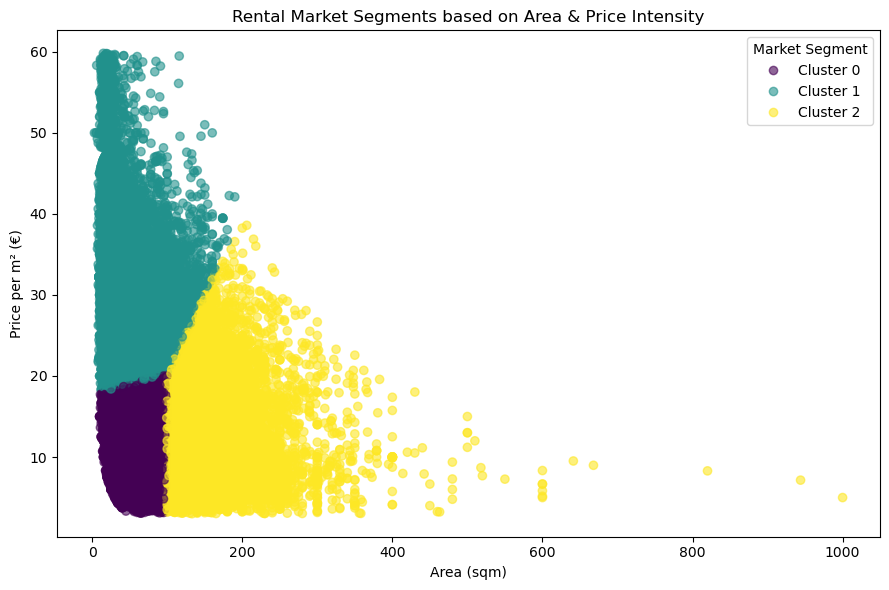

--- Cluster Statistics (Average Values) ---
         price_m2   area  cluster
cluster                          
0            12.3   64.6   123070
1            26.1   54.7    42304
2            11.9  132.5    42562


In [26]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    cluster_df['area'],
    cluster_df['price_m2'],
    c=cluster_df['cluster'],
    alpha=0.6
)
plt.xlabel('Area (sqm)')
plt.ylabel('Price per m² (€)')
plt.title('Rental Market Segments based on Area & Price Intensity')

handles, _ = scatter.legend_elements()
plt.legend(handles, [f'Cluster {i}' for i in range(optimal_k)],
           title='Market Segment')

plt.tight_layout()
plt.show()

stats = cluster_df.groupby('cluster').agg({
    'price_m2': 'mean',
    'area': 'mean',
    'cluster': 'count'
}).round(1)

print("--- Cluster Statistics (Average Values) ---")
print(stats)


In [27]:
cluster_names = {
    0: 'Compact Premium',
    1: 'Mid-size Urban',
    2: 'Spacious Value'
}

cluster_df['segment'] = cluster_df['cluster'].map(cluster_names)
print(cluster_df['segment'].value_counts())

segment
Compact Premium    123070
Spacious Value      42562
Mid-size Urban      42304
Name: count, dtype: int64


                 listings  median_daysActive  mean_daysActive
segment                                                      
Compact Premium    123070               14.1             90.5
Mid-size Urban      42304               14.2            103.6
Spacious Value      42562               19.0             73.8


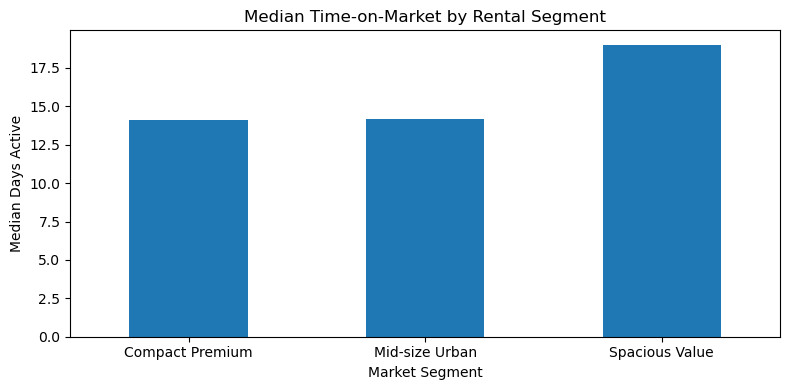

In [29]:
cluster_df['daysActive'] = df.loc[cluster_df.index, 'daysActive']

# Summary table
daysactive_summary = (
    cluster_df
    .groupby('segment')
    .agg(
        listings=('daysActive', 'count'),
        median_daysActive=('daysActive', 'median'),
        mean_daysActive=('daysActive', 'mean')
    )
    .round(1)
)
print(daysactive_summary)
median_days = daysactive_summary['median_daysActive']

# Plotting 
plt.figure(figsize=(8, 4))
median_days.plot(kind='bar')
plt.ylabel('Median Days Active')
plt.xlabel('Market Segment')
plt.title('Median Time-on-Market by Rental Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


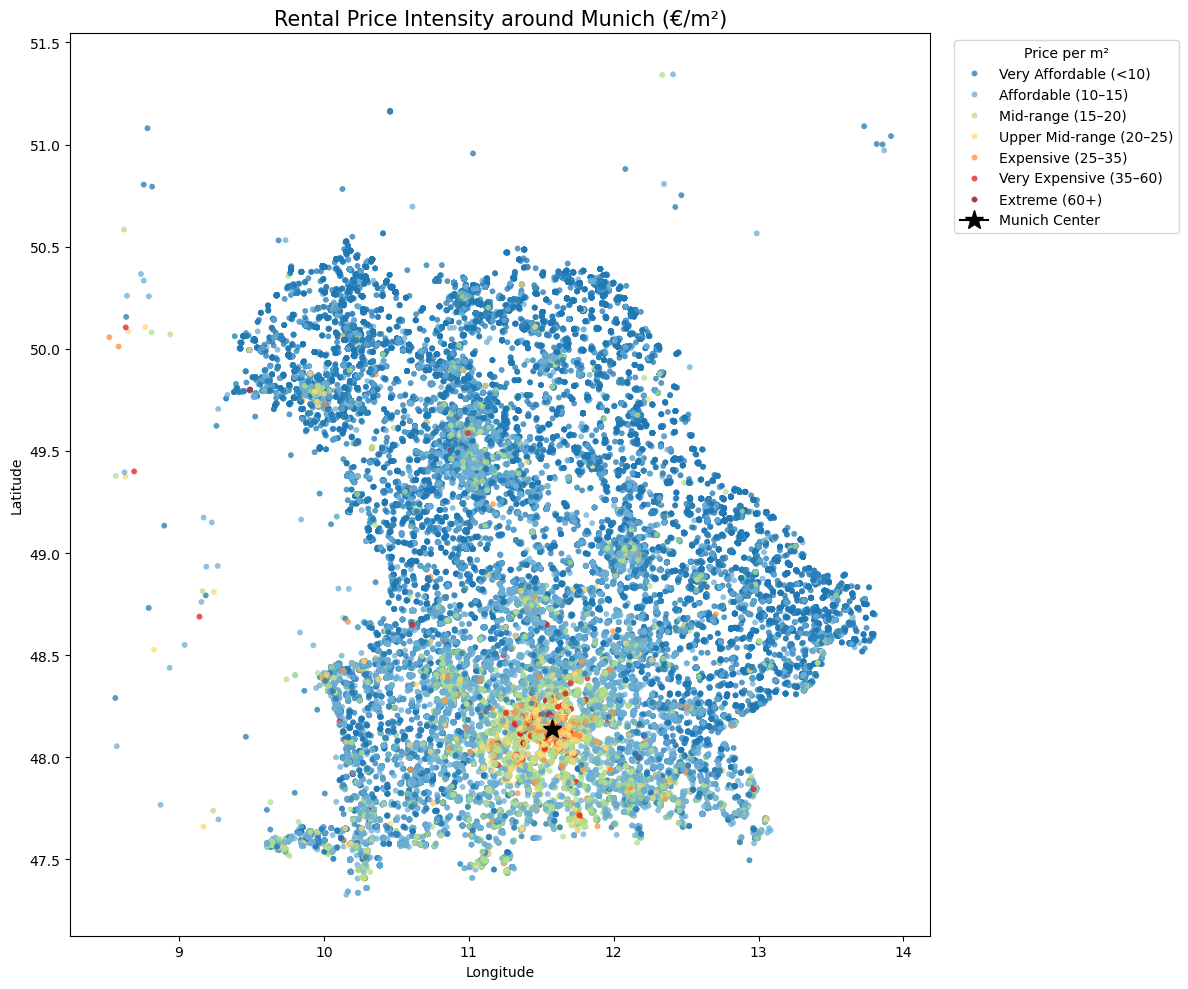

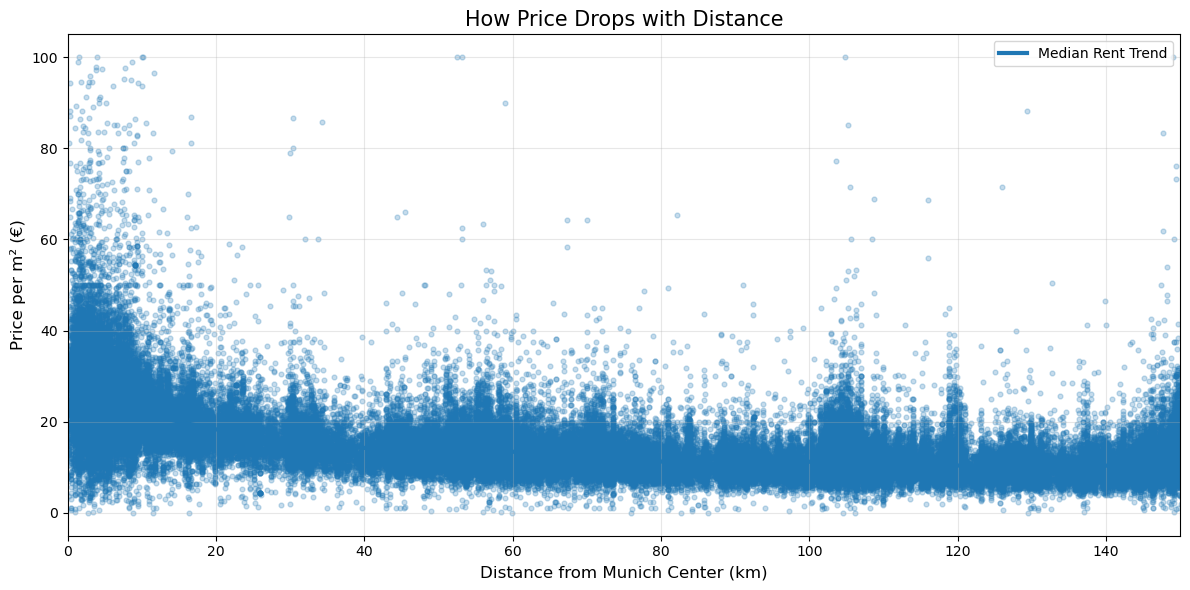

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
# setting reference point as munich centre at marian platz
MUNICH_LAT = 48.137154
MUNICH_LON = 11.576124

def haversine_distance(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # km

geo_df = df.dropna(subset=['lat', 'lon', 'price_m2']).copy()

# Slightly expanded Munich region
geo_df = geo_df[
    (geo_df['lat'] > 46.5) & (geo_df['lat'] < 51.5) &
    (geo_df['lon'] > 8.5) & (geo_df['lon'] < 14.5) &
    (geo_df['price_m2'] <= 100)   
]

# Distance to Munich
geo_df['dist_munich'] = haversine_distance(
    geo_df['lat'], geo_df['lon'],
    MUNICH_LAT, MUNICH_LON
)

#defining price ranges
price_bins = [0, 10, 15, 20, 25, 35, 60, 100]
price_labels = [
    'Very Affordable (<10)',
    'Affordable (10–15)',
    'Mid-range (15–20)',
    'Upper Mid-range (20–25)',
    'Expensive (25–35)',
    'Very Expensive (35–60)',
    'Extreme (60+)'
]

geo_df['price_category'] = pd.cut(
    geo_df['price_m2'],
    bins=price_bins,
    labels=price_labels,
    ordered=True,
    include_lowest=True
)


# colour palette

palette = {
    'Very Affordable (<10)': '#1f78b4',
    'Affordable (10–15)': '#6baed6',
    'Mid-range (15–20)': '#b2df8a',
    'Upper Mid-range (20–25)': '#fed976',
    'Expensive (25–35)': '#fd8d3c',
    'Very Expensive (35–60)': '#e31a1c',
    'Extreme (60+)': '#7f0000'
}

# plotting map
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=geo_df,
    x='lon',
    y='lat',
    hue='price_category',
    palette=palette,
    s=18,
    alpha=0.75,
    linewidth=0
)
plt.plot(
    MUNICH_LON,
    MUNICH_LAT,
    marker='*',
    color='black',
    markersize=14,
    label='Munich Center'
)
plt.title('Rental Price Intensity around Munich (€/m²)', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(
    title='Price per m²',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)
plt.tight_layout()
plt.show()

# plotting price vs distance
plt.figure(figsize=(12, 6))
plt.scatter(
    geo_df['dist_munich'],
    geo_df['price_m2'],
    alpha=0.25,
    s=12
)
geo_df['distance_band'] = pd.cut(
    geo_df['dist_munich'],
    bins=np.arange(0, 210, 10)
)
distance_price = (
    geo_df
    .groupby('distance_band', observed=True)['price_m2']
    .median()
    .reset_index()
)

distance_price['distance_km'] = distance_price['distance_band'].apply(lambda x: x.mid)
plt.plot(
    distance_price['distance_km'],
    distance_price['price_m2'],
    linewidth=3,
    label='Median Rent Trend'
)
plt.title('How Price Drops with Distance', fontsize=15)
plt.xlabel('Distance from Munich Center (km)', fontsize=12)
plt.ylabel('Price per m² (€)', fontsize=12)
plt.xlim(0, 150)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


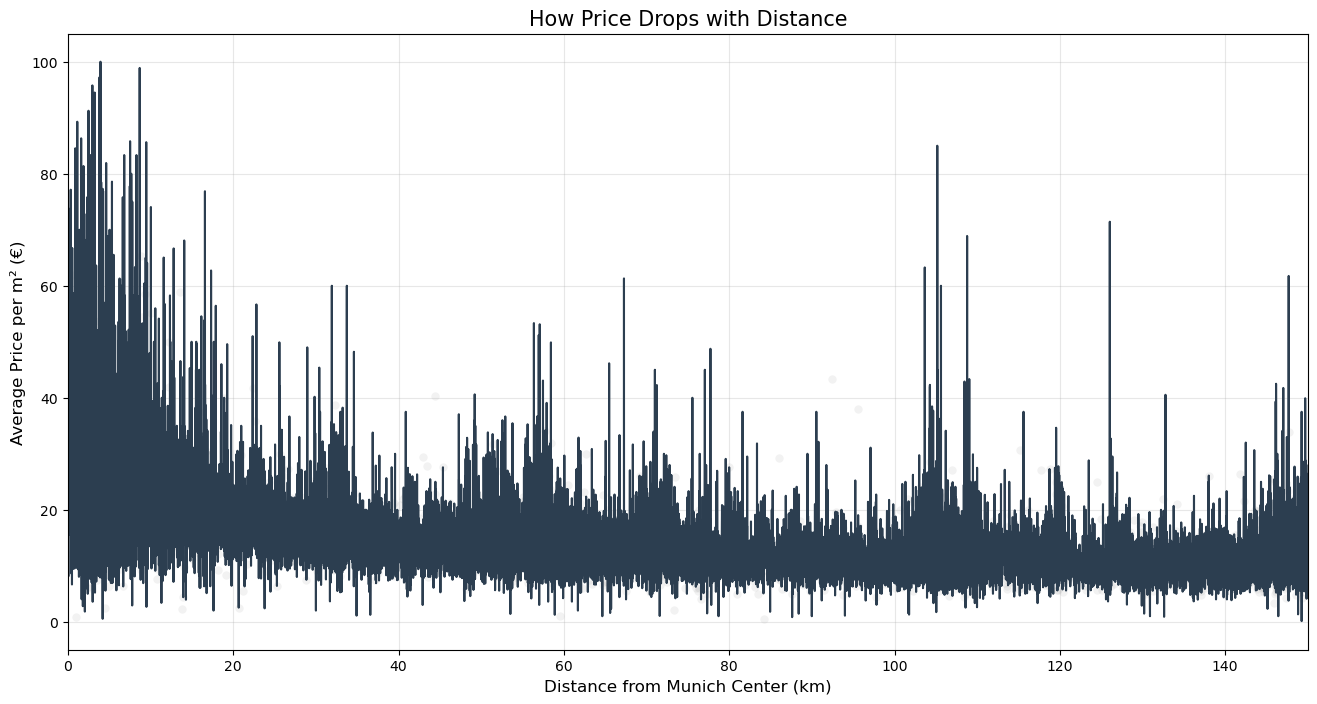

In [31]:
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=geo_df,
    x='dist_munich',
    y='price_m2',
    color='#2c3e50',
    errorbar=None
)
sns.scatterplot(data=geo_df.sample(5000), x='dist_munich', y='price_m2', alpha=0.1, color='gray')

plt.title('How Price Drops with Distance', fontsize=15)
plt.xlabel('Distance from Munich Center (km)', fontsize=12)
plt.ylabel('Average Price per m² (€)', fontsize=12)
plt.xlim(0, 150) # Focus on the first 150km
plt.grid(True, alpha=0.3)
plt.show()

### Price Determinants: Regression Analysis

A regression model was developed to quantify the impact of property characteristics and 
location factors on rental prices.


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     6774.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        00:35:12   Log-Likelihood:            -1.0517e+05
No. Observations:              208900   AIC:                         2.104e+05
Df Residuals:                  208892   BIC:                         2.104e+05
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.8829      0.021  

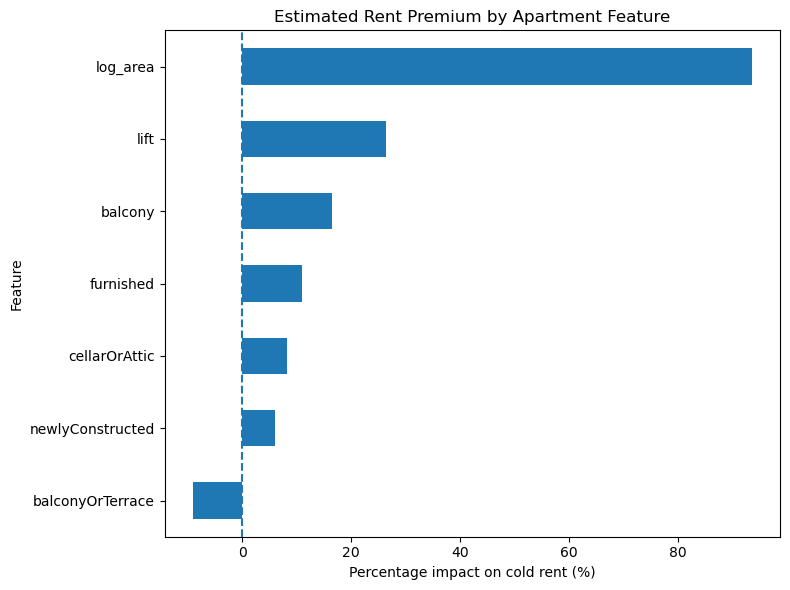

In [32]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df['log_price'] = np.log(df['price'])
df['log_area'] = np.log(df['area'])

features = [
    'log_area',
    'lift',
    'balcony',
    'balconyOrTerrace',
    'cellarOrAttic',
    'furnished',
    'newlyConstructed'
]

X = df[features]

import statsmodels.api as sm

y = df['log_price']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

coef = model.params.drop('const')
conf = model.conf_int().drop('const')
conf.columns = ['lower', 'upper']

impact_pct = (np.exp(coef) - 1) * 100
impact_pct = impact_pct.sort_values()

plt.figure(figsize=(8, 6))
impact_pct.plot(kind='barh')
plt.axvline(0, linestyle='--')
plt.title('Estimated Rent Premium by Apartment Feature')
plt.xlabel('Percentage impact on cold rent (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



## Market Liquidity Analysis (Days Active)

Market liquidity was analyzed using the number of days a listing remains active as a proxy 
for demand and pricing efficiency.



/var/folders/y3/9gvskmz92w9497s4v4tvb1k80000gn/T/ipykernel_24949/151427836.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['city', 'price_bucket'])


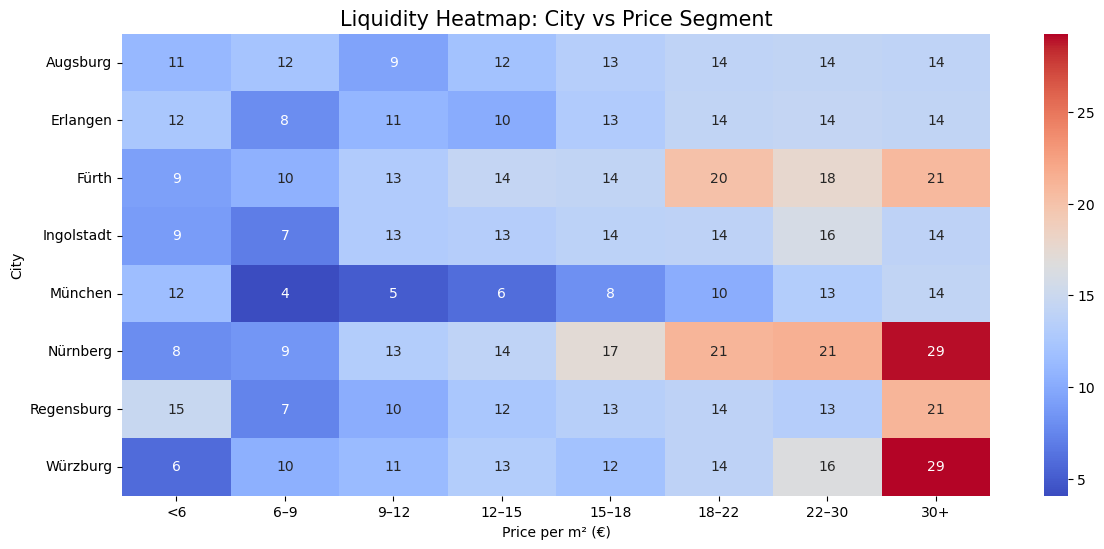

In [33]:
liq_df = df.copy()
liq_df = liq_df[
    (liq_df['price_m2'] > 3) & (liq_df['price_m2'] < 100) &      
    (liq_df['daysActive'] > 0) & (liq_df['daysActive'] < 365)  
].dropna(subset=['price_m2', 'daysActive'])

# creating price bins

price_bins = [0, 6, 9, 12, 15, 18, 22, 30, 40]
price_labels = [
    "<6", "6–9", "9–12", "12–15", "15–18", "18–22", "22–30", "30+"
]

liq_df['price_bucket'] = pd.cut(
    liq_df['price_m2'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)
city_liquidity = (
    liq_df
    .groupby(['city', 'price_bucket'])
    .agg(median_days=('daysActive', 'median'))
    .reset_index()
)

top_cities = liq_df['city'].value_counts().head(8).index
city_liquidity = city_liquidity[city_liquidity['city'].isin(top_cities)]

pivot = city_liquidity.pivot(
    index='city',
    columns='price_bucket',
    values='median_days'
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")

plt.title("Liquidity Heatmap: City vs Price Segment", fontsize=15)
plt.xlabel("Price per m² (€)")
plt.ylabel("City")
plt.show()


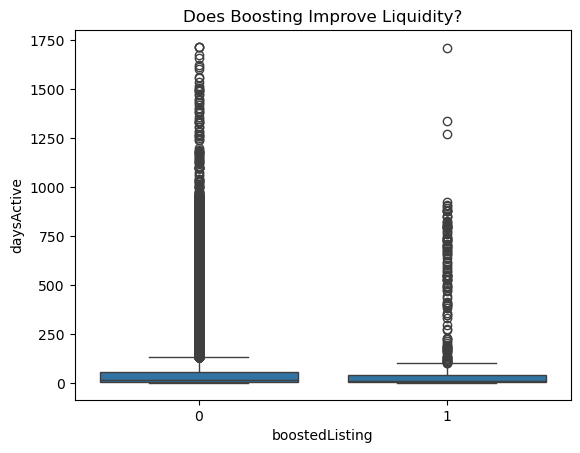

boostedListing
0    208157
1       743
Name: count, dtype: int64


In [34]:
sns.boxplot(
    data=df,
    x='boostedListing',
    y='daysActive'
)
plt.title("Does Boosting Improve Liquidity?")
plt.show()

print(df['boostedListing'].value_counts())


In [35]:
df['offerer_commission'].value_counts()

offerer_commission
0    112552
1     96348
Name: count, dtype: int64

In [36]:
# commission analysis, 
summary = (df
    .groupby('offerer_commission')
    .agg(
        median_price_m2=('price_m2', 'median'),
        median_days_active=('daysActive', 'median'),
        listings=('daysActive', 'count')
    )
)
print("Impact of Offerer Commission on Price and Liquidity:\n")
print(summary)
if 1 in summary.index and 0 in summary.index:
    price_diff = summary.loc[1, 'median_price_m2'] - summary.loc[0, 'median_price_m2']
    days_diff = summary.loc[1, 'median_days_active'] - summary.loc[0, 'median_days_active']

    print(
        f"\nListings with commission are priced "
        f"{price_diff:+.1f} €/m² compared to no-commission listings "
        f"and stay on the market {days_diff:+.0f} days longer on median."
    )


Impact of Offerer Commission on Price and Liquidity:

                    median_price_m2  median_days_active  listings
offerer_commission                                               
0                         11.000000           14.999584    112552
1                         15.942029           14.309990     96348

Listings with commission are priced +4.9 €/m² compared to no-commission listings and stay on the market -1 days longer on median.


## TEXTUAL ANALYSIS

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/piyushnandwani/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


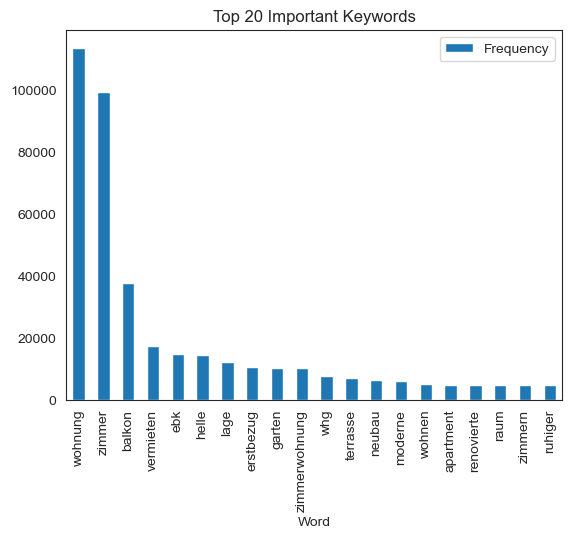

In [44]:
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
german_stop_words = set(stopwords.words('german'))

# removing the unnecessary words
def clean_keywords(text):
    text = str(text).lower()
    # keep alphabets only (remove the numbers and symbols)
    words = re.findall(r'\b[a-z]{3,}\b', text) 
    # filter stopwords
    important_words = [w for w in words if w not in german_stop_words]
    return important_words

# extract words from title
all_titles = ' '.join(df['title'].astype(str))
filtered_words = clean_keywords(all_titles)

# count now
from collections import Counter
common_words = Counter(filtered_words).most_common(20)

# Make group
import pandas as pd
import matplotlib.pyplot as plt
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
words_df.plot(kind='bar', x='Word', y='Frequency', title='Top 20 Important Keywords')
plt.show()

In [45]:
# Sentiment Analysis

In [46]:
!pip install TextBlob
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_score'] = df['title'].apply(get_sentiment)

In [47]:
#1.0 (Positive  Means title has good words to attract tenants 
#0.0 (Neutral)  Means title has normal words 
#-1.0 (Negative) Means title has negative words (its very rare in real estate)
print(df[['title', 'sentiment_score']].head(10))

                                                title  sentiment_score
0   ihr neues zuhause - 3,5 zimmer im 1. obergesch...              0.0
1                                    2 zimmer wohnung              0.0
2           1zimmerwohnung möbliert an we heim-fahrer              0.0
3     [tauschwohnung] 1zimmer appartement bogenhausen              0.0
4                 große 4,5 zw würzburg ggü. cinemaxx              0.0
5                   schöne helle 2 zimmerwohnung 73m2              0.0
6   schöne und helle 3,5 zimmer dachgeschosswohnun...              0.0
8   schöne 3zi - wohnung in attraktiver lage aisin...              0.0
9   dachgeschosswohnung/ cooles loft über zwei ebe...              0.0
10               wohnung in ruhiger lage zu vermieten              0.0


In [48]:
#  top 5 sentiments based on score
df.sort_values(by='sentiment_score', ascending=False)[['title', 'sentiment_score']].head()

,title,sentiment_score
37739,voll möblierte2-zimmer-wohnung mit ebk in best...,1.0
66698,best offer for 22 square meter apartment in ma...,1.0
102860,imposante gartenanlage - exquisite 4-zi.-maiss...,1.0
116645,gemütliche 3 zimmerwohnung mit kamin - ideal f...,1.0
157378,ideal für paare: großzügig - gemütlich - bezah...,1.0


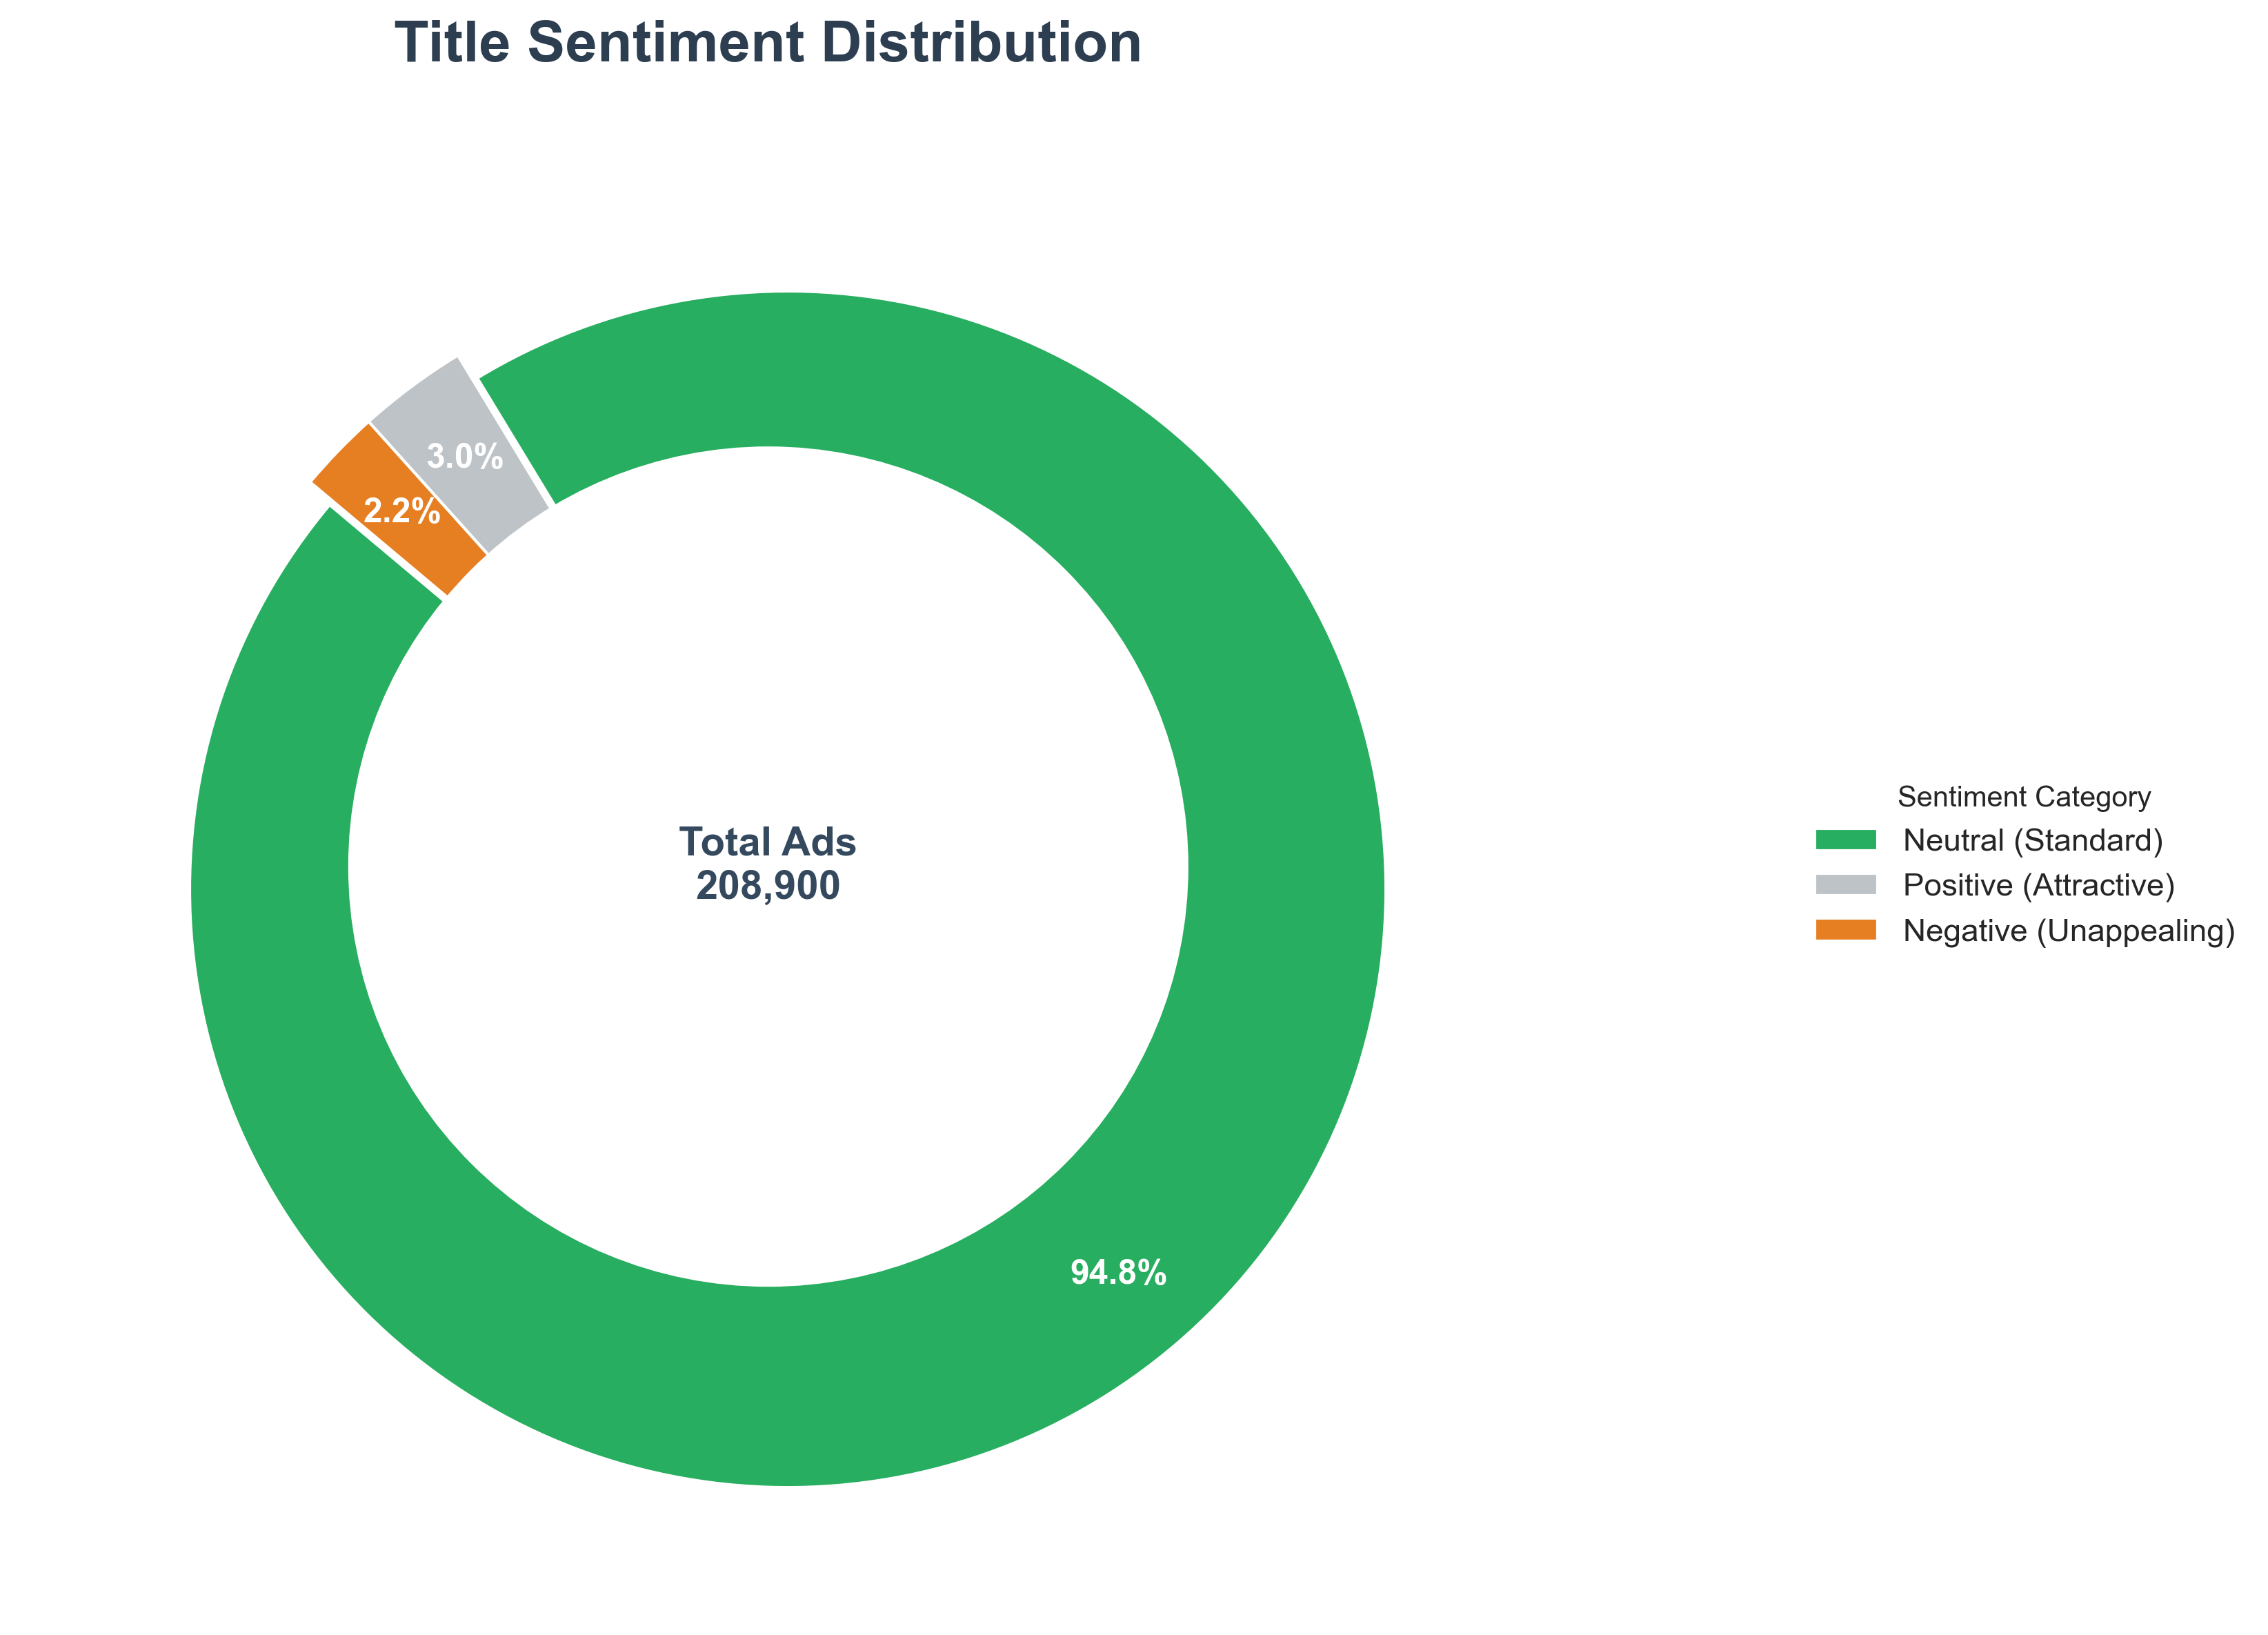

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Categorization Logic (Professional Bucketing)
def categorize_sentiment(score):
    if score > 0:
        return 'Positive (Attractive)'
    elif score < 0:
        return 'Negative (Unappealing)'
    else:
        return 'Neutral (Standard)'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# 2. Data Summary (Counts & Percentages)
sentiment_counts = df['sentiment_category'].value_counts()
sentiment_pct = df['sentiment_category'].value_counts(normalize=True) * 100

# 3. Visualization: High-Resolution Donut Chart
plt.figure(figsize=(12, 8), dpi=300)
sns.set_style("white")

# Colors: Green for Positive, Grey for Neutral, Red/Orange for Negative
colors = ['#27ae60', '#bdc3c7', '#e67e22'] # Emerald, Silver, Carrot

# Create Pie Chart
plt.pie(sentiment_counts, labels=None, autopct='%1.1f%%', startangle=140, 
        colors=colors, pctdistance=0.85, explode=(0.05, 0, 0), 
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'})

# Transform into Donut Chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. Legend & Title
plt.legend(sentiment_counts.index, title="Sentiment Category", loc="center right", 
           bbox_to_anchor=(1, 0, 0.5, 1), frameon=False, fontsize=11)

plt.title('Title Sentiment Distribution', 
          fontsize=20, fontweight='bold', pad=20, color='#2c3e50')

# Adding a Total Count label in the center
plt.text(0, 0, f'Total Ads\n{len(df):,}', ha='center', va='center', 
         fontsize=14, fontweight='bold', color='#34495e')

plt.tight_layout()
plt.show()

### Grouped Analysis (Average rent per Score)
This tells, is there any relationship between the 'vibe' (sentiment) of a property title and its 'rent'?
#### Highly positive: if the bar is uperside, then this means that people use more "attractive" and "positive" words for expensive (luxury) properties.
#### NeutralL: if the bar is upperside, then this means that even the titles of expensive properties are completely simple and factual, there is no need to "spice" them up.

sentiment_category
Negative            939.174176
Neutral            1174.951173
Highly Positive    1276.025091
Positive           1285.238037
Name: totalRent, dtype: float64


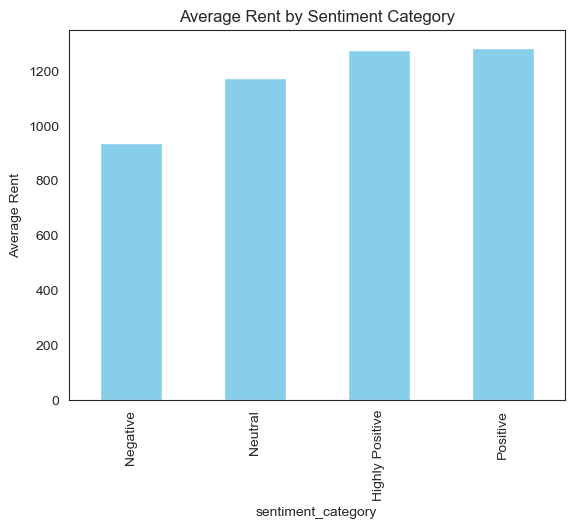

In [50]:
# Sentiment to divide in category
def categorize_sentiment(score):
    if score == 0: return 'Neutral'
    if score > 0 and score < 0.5: return 'Positive'
    if score >= 0.5: return 'Highly Positive'
    return 'Negative'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# Check average rent based on category
avg_price_sentiment = df.groupby('sentiment_category')['totalRent'].mean().sort_values()
print(avg_price_sentiment)

# Bar chart 
avg_price_sentiment.plot(kind='bar', color='skyblue', title='Average Rent by Sentiment Category')
plt.ylabel('Average Rent')
plt.show()

Top 10 Cities with most 'Highly Positive' titles (by Count):
city
München       982
Nürnberg      545
Augsburg      179
Regensburg    134
Ingolstadt     78
Würzburg       75
Fürth          71
Passau         58
Bayreuth       49
Erlangen       46
Name: count, dtype: int64


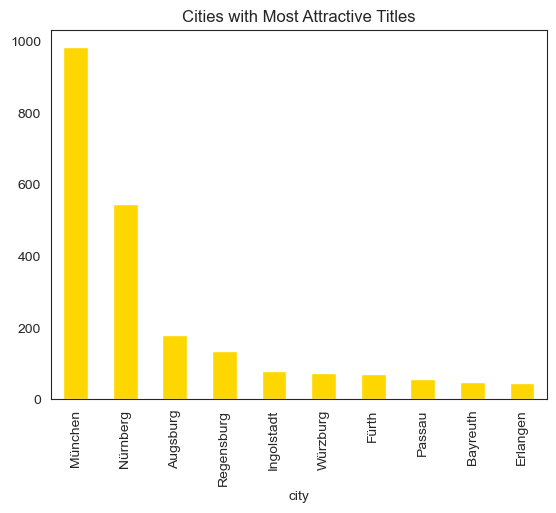

In [51]:
# Counting cities by filtering out positive categories
top_positive_cities = df[df['sentiment_category'] == 'Highly Positive']['city'].value_counts().head(10)

print("Top 10 Cities with most 'Highly Positive' titles (by Count):")
print(top_positive_cities)

# Graph
top_positive_cities.plot(kind='bar', color='gold', title='Cities with Most Attractive Titles')
plt.show()

Top 10 Cities with the most 'Aggressive' Marketing (% wise):
city
Bad Brückenau                8.552632
Feucht                       8.376963
Holzkirchen                  5.660377
Gerolzhofen                  5.291005
Röthenbach an der Pegnitz    5.291005
Diedorf                      4.687500
Vaterstetten                 4.562738
Schwaig bei Nürnberg         4.411765
Zwiesel                      4.379562
Oberasbach                   4.285714
Name: Highly Positive, dtype: float64


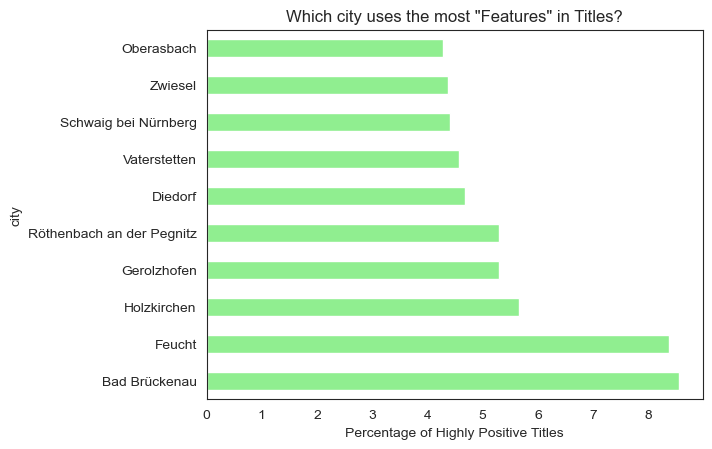

In [52]:
# 1. First, count the total listings for each city.
city_counts = df['city'].value_counts()

# 2. Only take cities that have at least 100 listings (so that the data remains reliable).
popular_cities = city_counts[city_counts > 100].index

# 3. Finding out the sentiment percentage of these popular cities
city_sentiment_pct = pd.crosstab(df['city'], df['sentiment_category'], normalize='index') * 100

# 4. Making it to the top 10 in terms of positive cases
top_marketing_cities = city_sentiment_pct.loc[popular_cities].sort_values(by='Highly Positive', ascending=False).head(10)

print("Top 10 Cities with the most 'Aggressive' Marketing (% wise):")
print(top_marketing_cities['Highly Positive'])

# Graph 
top_marketing_cities['Highly Positive'].plot(kind='barh', color='lightgreen')
plt.xlabel('Percentage of Highly Positive Titles')
plt.title('Which city uses the most "Features" in Titles?')
plt.show()

## #Clustering (Market Segmentation)

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. Text ko numbers mein convert karna (Vectorization)
# We are taking the top 500 words that are used the most.
vectorizer = TfidfVectorizer(max_features=500, stop_words=list(german_stop_words))
X = vectorizer.fit_transform(df['title'].astype(str))

# 2. Creating clusters (let's say we want to create 3 groups)
# Group 0: Budget, Group 1: Family, Group 2: Luxury 
kmeans = KMeans(n_clusters=3, random_state=42)
df['market_segment'] = kmeans.fit_predict(X)

# 3. Look at the top words of each cluster to find out what the group is.
print("--- Keywords per Market Segment ---")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(3):
    print(f"\nCluster {i} (Top Words):", end='')
    for ind in order_centroids[i, :5]:
        print(f' {terms[ind]}', end='')

--- Keywords per Market Segment ---

Cluster 0 (Top Words): erstbezug lage ruhiger zimmer wohnung
Cluster 1 (Top Words): schöne wohnung zimmer balkon helle
Cluster 2 (Top Words): wohnung zimmer balkon vermieten zi

--- Professional Market Segmentation Report ---
market_segment_name
Feature-Focused (Balkon/EBK)             1406.23
Attractive/Descriptive (Schöne/Helle)    1153.02
Simple/Transactional (Rent/Date)         1066.28
Name: totalRent, dtype: float64


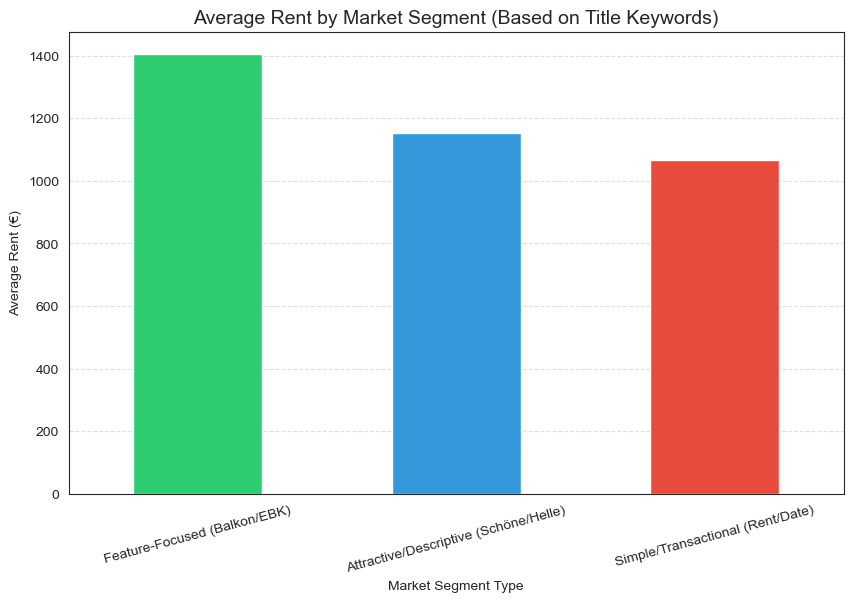

In [54]:
#Business Insight (avg rent of each segment)

# 1. Mapping numbers to meaningful names
segment_map = {
    0: 'Feature-Focused (Balkon/EBK)',
    1: 'Simple/Transactional (Rent/Date)',
    2: 'Attractive/Descriptive (Schöne/Helle)'
}

# 2. Create a new column with this name
df['market_segment_name'] = df['market_segment'].map(segment_map)

# 3. Check the analysis now (with rent)
final_analysis = df.groupby('market_segment_name')['totalRent'].mean().sort_values(ascending=False).round(2)

print("--- Professional Market Segmentation Report ---")
print(final_analysis)

# 4. Graph 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
final_analysis.plot(kind='bar', color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Average Rent by Market Segment (Based on Title Keywords)', fontsize=14)
plt.ylabel('Average Rent (€)')
plt.xlabel('Market Segment Type')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

--- Cleaned Platform Average Rent ---
platforms
immoscout     1303.95
immowelt      1225.79
immobilie1    1225.45
ebay           984.88
wggesucht      811.97
Name: totalRent, dtype: float64


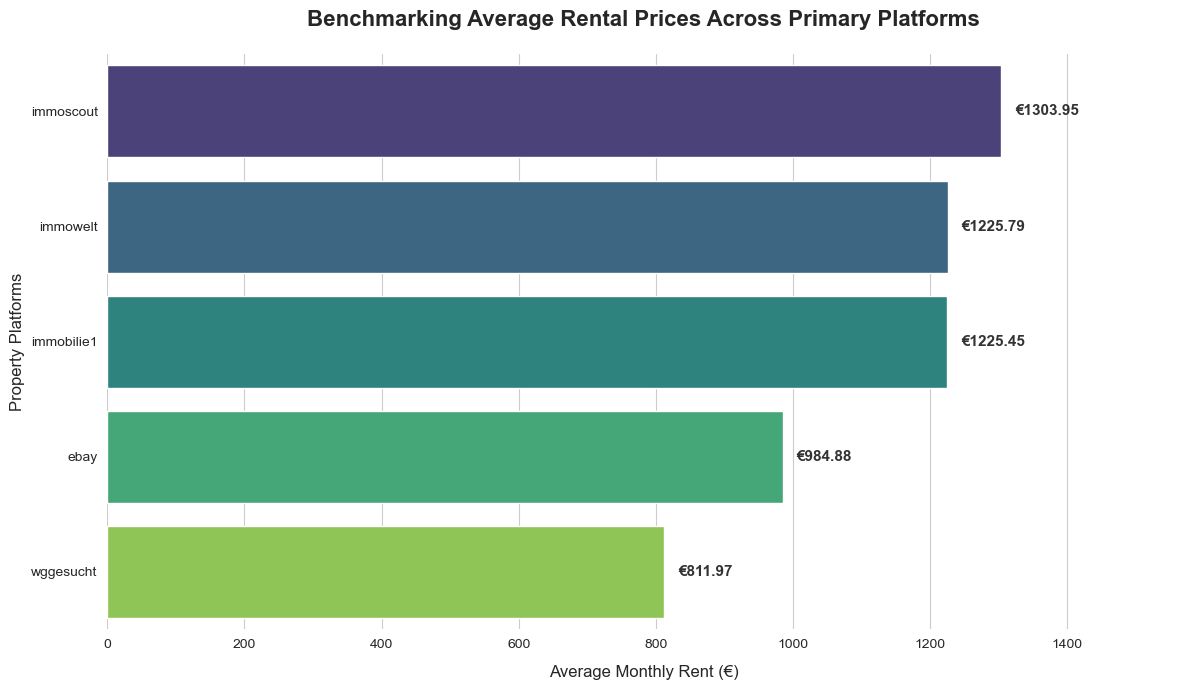

In [55]:
###Pricing Strategy (Avg rent across primary platforms)

# 1. If the data is in list format '['A', 'B']', then first convert it to a list.

import ast
def clean_platform_list(x):
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except:
            return [x]
    return [x]

# Make a copy so that the original data is not corrupted.
df_platforms = df.copy()
df_platforms['platforms'] = df_platforms['platforms'].apply(clean_platform_list)

# 2. Explode karein ((A row has 2 platforms, which will change into 2 rows))
df_exploded = df_platforms.explode('platforms')

# 3. Clear platform names (extra spaces or caps)
df_exploded['platforms'] = df_exploded['platforms'].str.strip().str.lower()

# 4. Filter only the top 5 platforms
target_platforms = ['immowelt', 'immoscout', 'wggesucht', 'immobilie1', 'ebay']
df_final_platforms = df_exploded[df_exploded['platforms'].isin(target_platforms)]

# 5. Final Average Rent calculation
platform_avg_rent = df_final_platforms.groupby('platforms')['totalRent'].mean().sort_values(ascending=False).round(2)

print("--- Cleaned Platform Average Rent ---")
print(platform_avg_rent)

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setting professional style (Modern/Corporate look)
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# 2. Horizontal Bar Plot (horizontal bars for labels)
# 'platform_avg_rent' 
ax = sns.barplot(x=platform_avg_rent.values, 
                 y=platform_avg_rent.index, 
                 palette="viridis", # Gradient color 
                 hue=platform_avg_rent.index, 
                 legend=False)

# 3. actual value at the end of each bar
for p in ax.patches:
    ax.annotate(f'€{p.get_width():.2f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', 
                xytext=(10, 0), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold', color='#333333')

# 4. clean label and titles
plt.title('Benchmarking Average Rental Prices Across Primary Platforms', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Monthly Rent (€)', fontsize=12, labelpad=10)
plt.ylabel('Property Platforms', fontsize=12)

# 5. Spines hatana 
sns.despine(left=True, bottom=True)

# 6. X-axis- Increase the limit so that text labels fit.
plt.xlim(0, platform_avg_rent.max() * 1.2)

plt.tight_layout()
plt.show()

--- Average Days an Ad stays Active per Platform ---
platforms
ebay           97.4
immoscout     111.8
immowelt      125.3
wggesucht     568.5
immobilie1    611.6
Name: daysActive, dtype: float64


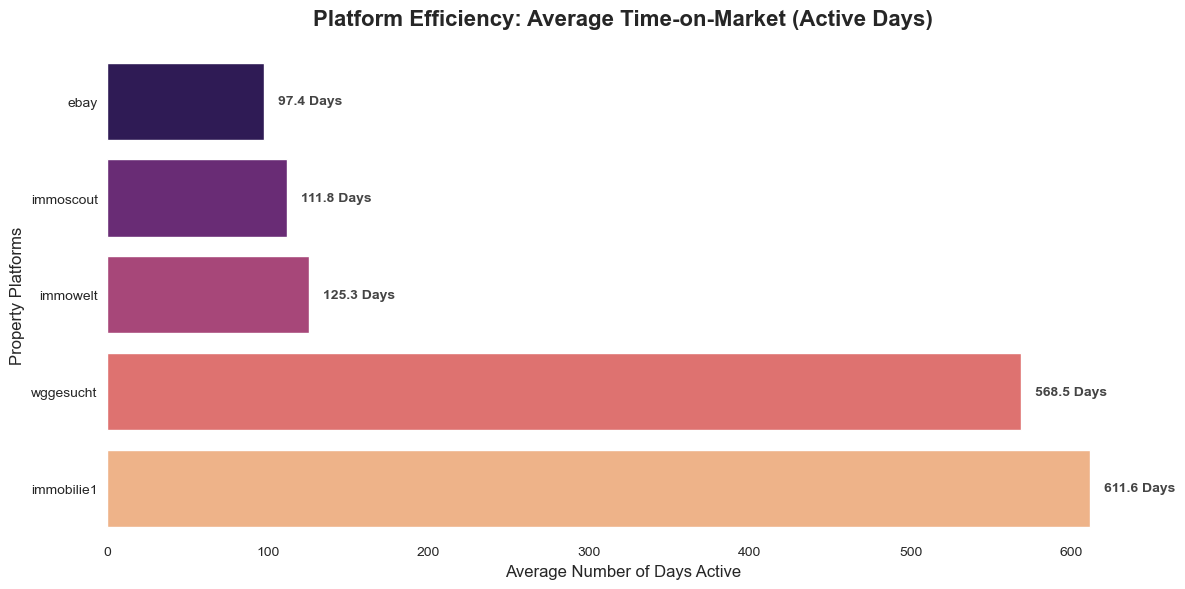

In [56]:
#Time on Market (ToM) Analysis

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Platform-wise Active Days ka average nikalna
# 'source_id' aur 'active_days' (ya aapka jo bhi column name hai) use karein
platform_speed = df_final_platforms.groupby('platforms')['daysActive'].mean().sort_values().round(1)

print("--- Average Days an Ad stays Active per Platform ---")
print(platform_speed)

# 2. Professional Visualization (Corporate Look)
plt.figure(figsize=(12, 6))
sns.set_style("white")

# Horizontal Bar Chart for Speed
ax = sns.barplot(x=platform_speed.values, 
                 y=platform_speed.index, 
                 palette="magma", 
                 hue=platform_speed.index, 
                 legend=False)

# 3. Data Labels lagana (Precise analysis dikhane ke liye)
for p in ax.patches:
    ax.annotate(f'{p.get_width()} Days', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                xytext=(10, 0), textcoords='offset points', 
                va='center', fontweight='bold', color='#444444')

# 4. Labels and Title
plt.title('Platform Efficiency: Average Time-on-Market (Active Days)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Number of Days Active', fontsize=12)
plt.ylabel('Property Platforms', fontsize=12)

# remove spines 
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [57]:
##Platform Dominance & Market Share Analysis

#Sorted Horizontal Volume Bar
#This analysis quantifies the supply-side volume across the primary real estate channels. By 'exploding' multi-platform listings, we have eliminated 
#data duplication to reveal the true market share of each provider. Immoscout emerges as the primary inventory hub, hosting 98,604 of the total unique
#advertisements, while niche platforms serve specialized segments."




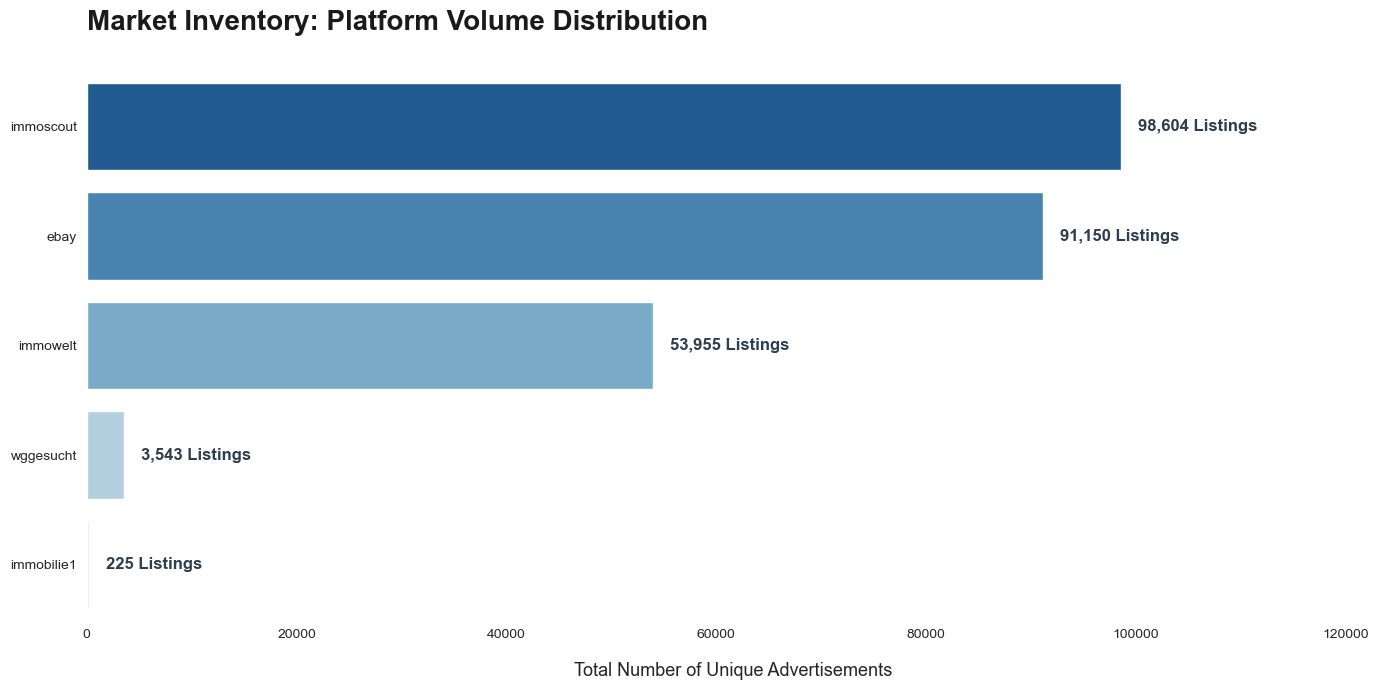

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: VARIABLE LINKING 
try:
    analysis_df = df_final_platforms
except NameError:
    analysis_df = df

# variable for Platform counts 
ad_counts = analysis_df['platforms'].value_counts() 

# --- STEP 2: PLOTTING ---
plt.figure(figsize=(14, 7), dpi=100)
sns.set_style("white")

# 'The Blues_r color map is used to display top-performing platforms in dark blue.
ax = sns.barplot(
    x=ad_counts.values, 
    y=ad_counts.index, 
    palette="Blues_r", 
    hue=ad_counts.index, 
    legend=False
)

# --- STEP 3: ANNOTATIONS (Perfectly Aligned) ---
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width):,} Listings', 
                (width, p.get_y() + p.get_height() / 2),
                xytext=(12, 0), textcoords='offset points', 
                va='center', fontsize=12, fontweight='bold', color='#2c3e50')

# --- STEP 4:  FINISHING ---
plt.title('Market Inventory: Platform Volume Distribution', 
          fontsize=20, fontweight='bold', loc='left', pad=30, color='#1a1a1a')
plt.xlabel('Total Number of Unique Advertisements', fontsize=13, labelpad=15)
plt.ylabel('') # Platform names are already clear on Y-axis

# Modern Minimalist Look
sns.despine(left=True, bottom=True)

# Extra space for labels
plt.xlim(0, ad_counts.max() * 1.25) 
plt.tight_layout()
plt.show()

In [59]:
#estateTpe Segmentation per Platform"

<Figure size 1400x800 with 0 Axes>

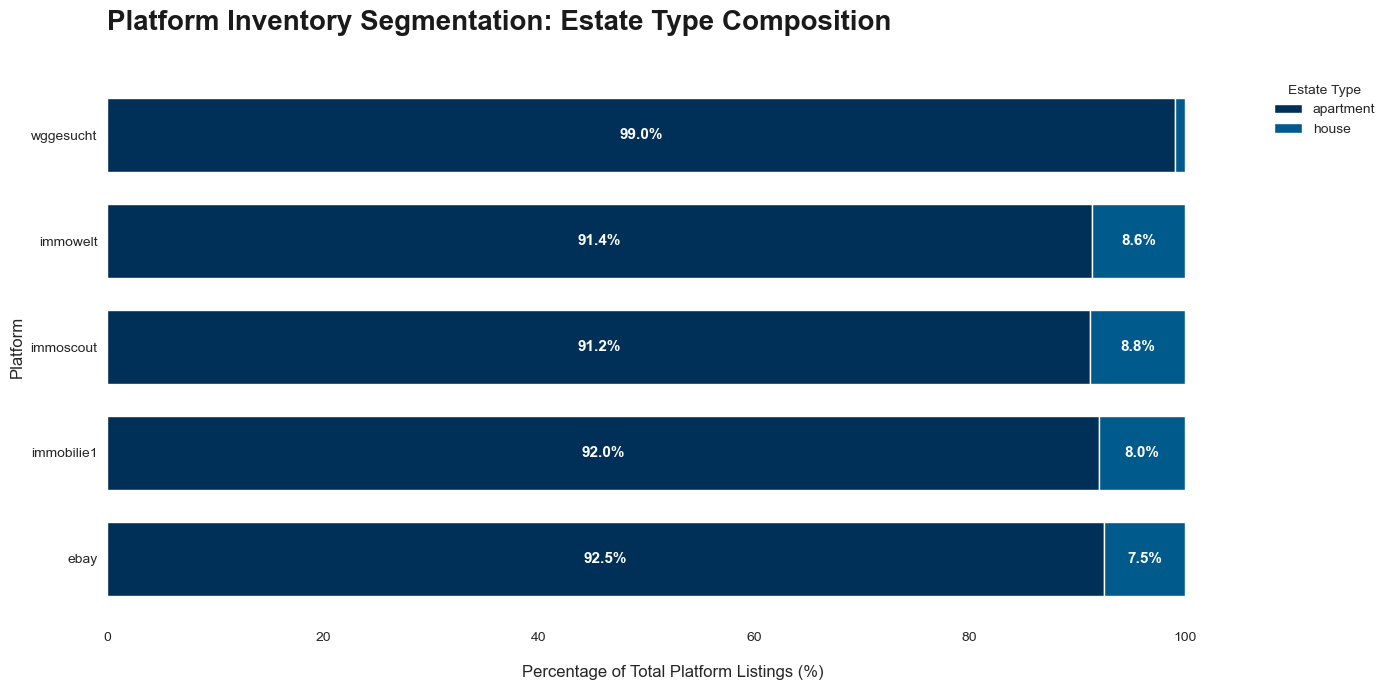

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: DYNAMIC VARIABLE LINKING ---
try:
    source_df = df_final_platforms
except NameError:
    source_df = df

# --- STEP 2: DATA AGGREGATION (Macro Composition) ---
# 'Calculating the inventory mix using platforms and estate types.
composition_data = source_df.groupby(['platforms', 'estateType']).size().unstack(fill_value=0)

# --- STEP 3: NORMALIZE TO 100% ---
composition_pct = composition_data.div(composition_data.sum(axis=1), axis=0) * 100

# --- STEP 4: VISUALIZATION SETUP ---
plt.figure(figsize=(14, 8), dpi=100)
sns.set_style("white")

#Color Palette (BMW/SAP Standard)
colors = ['#003057', '#005a8c', '#419ad9', '#7ab8e1', '#b3d7ee']

# Plotting using 'composition_pct'
ax = composition_pct.plot(kind='barh', stacked=True, color=colors, figsize=(14, 7), width=0.7)

# --- STEP 5: SMART ANNOTATIONS ---
for p in ax.patches:
    width = p.get_width()
    if width > 5:  
        x, y = p.get_xy() 
        ax.annotate(f'{width:.1f}%', 
                    (x + width/2, y + p.get_height()/2), 
                    ha='center', va='center', 
                    fontsize=11, fontweight='bold', color='white')

# --- STEP 6:  FINISHING ---
plt.title('Platform Inventory Segmentation: Estate Type Composition', 
          fontsize=20, fontweight='bold', pad=30, loc='left', color='#1a1a1a')
plt.xlabel('Percentage of Total Platform Listings (%)', fontsize=12, labelpad=15)
plt.ylabel('Platform', fontsize=12)

# Legend clean look
plt.legend(title='Estate Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Clean spines for a modern look
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [61]:
##Strategic Inventory Segmentation: Platform Portfolio Composition"

##We have clustered 15+ property sub-types into 6 strategic groups to highlight core market trends. 
#This visualization reveals the structural differences between platforms: 
#while some cater to the mass-market 'Standard Apartments' segment, others clearly dominate in niche categories like 'Shared Living' and 'Luxury' segments."

<Figure size 5400x2700 with 0 Axes>

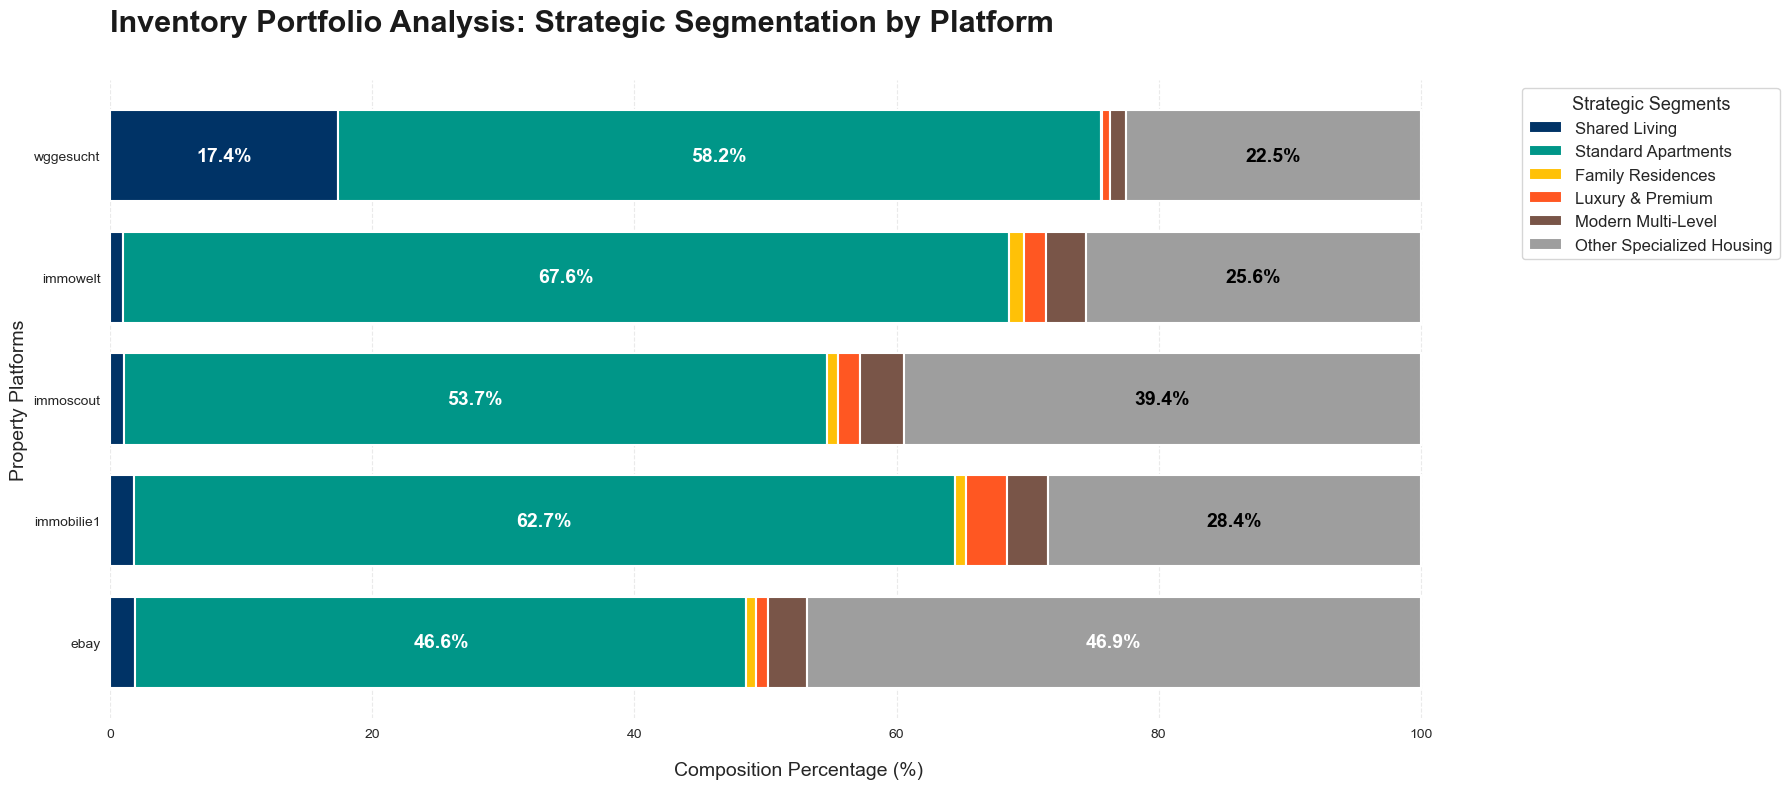

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: AUTOMATIC VARIABLE LINKING 
try:
    analysis_df = df_final_platforms
except NameError:
    analysis_df = df

# --- STEP 2: STRATEGIC GROUPING FUNCTION ---
def strategic_grouping(x):
    x = str(x).strip()
    # Categorizing into high-level business groups
    if x in ['sharedApartment', 'Shared_Apartment']: return 'Shared Living'
    if x in ['Penthouse', 'villa', 'Loft']: return 'Luxury & Premium'
    if x in ['singleFamilyHouse', 'multiFamilyHouse', 'bungalow']: return 'Family Residences'
    if x in ['midFloorApartment', 'groudFloorApartment']: return 'Standard Apartments'
    if x in ['maisonetteApartment', 'terracedApartment', 'terraceHouse']: return 'Modern Multi-Level'
    return 'Other Specialized Housing'

# Applying grouping on the correct source variable
analysis_df['strategic_group'] = analysis_df['estateTypeSpecified'].apply(strategic_grouping)

# --- STEP 3: DATA PREPARATION ---
group_order = ['Shared Living', 'Standard Apartments', 'Family Residences', 
               'Luxury & Premium', 'Modern Multi-Level', 'Other Specialized Housing']

# Creating the segment matrix
segment_matrix = pd.crosstab(analysis_df['platforms'], analysis_df['strategic_group'], normalize='index') * 100
segment_matrix = segment_matrix.reindex(columns=group_order)

# --- STEP 4: HIGH-CONTRAST VISUALIZATION ---
plt.figure(figsize=(18, 9), dpi=300) 
sns.set_style("white")

# High-Visibility  Palette
corporate_colors = ['#003366', '#009688', '#FFC107', '#FF5722', '#795548', '#9E9E9E']

ax = segment_matrix.plot(kind='barh', stacked=True, color=corporate_colors, 
                         figsize=(18, 8), width=0.75, edgecolor='#ffffff', linewidth=1.5)

# --- STEP 5: SMART ANNOTATIONS ---
for p in ax.patches:
    width = p.get_width()
    if width > 4.5: 
        x, y = p.get_xy() 
        # Contrast logic
        color = 'white' if width > 40 or x < 10 else 'black'
        ax.annotate(f'{width:.1f}%', 
                    (x + width/2, y + p.get_height()/2), 
                    ha='center', va='center', 
                    fontsize=14, fontweight='bold', color=color)

# --- STEP 6: STYLING & BRANDING ---
plt.title('Inventory Portfolio Analysis: Strategic Segmentation by Platform', 
          fontsize=22, fontweight='bold', pad=35, loc='left', color='#1a1a1a')
plt.xlabel('Composition Percentage (%)', fontsize=14, labelpad=15)
plt.ylabel('Property Platforms', fontsize=14)

plt.legend(title='Strategic Segments', bbox_to_anchor=(1.02, 1), 
           loc='upper left', frameon=True, fontsize=12, title_fontsize=13)

# Grid and Spines for clean look
plt.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()